# Binary Classification Framework: One vs All Approach

This notebook implements binary classifiers using a one-vs-all strategy for multiclass fault detection in the 3W dataset. It combines:

- **Data structure** from the supervised learning approach with proper train/test separation and cross-validation folds
- **Architecture approach** from the OTC notebook with LSTM-based models for time series classification
- **Binary classification strategy** where each classifier distinguishes one specific fault class from all others

## Objectives

1. Load processed windowed data with cross-validation structure
2. Train binary classifiers (one vs all) for each fault class
3. Evaluate performance across different folds and classes
4. Compare accuracy and effectiveness of each binary classifier

## Key Features

- **Proper data separation**: Uses train/test splits and cross-validation folds
- **Windowed sequences**: Time series data prepared for LSTM models
- **One-vs-all strategy**: Individual binary classifiers for each fault type
- **Comprehensive evaluation**: Performance metrics across folds and classes

# Section 1: Load Processed Data

Load the processed windowed data from the data treatment pipeline including cross-validation folds and windowed sequences.

In [1]:
# ============================================================
# LOAD 3W DATASET - Using Supervised Learning Structure
# ============================================================

import sys
import numpy as np
import pandas as pd
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append("../../src")
from src import config
from src.supervised_classification import (
    load_3w_data,
    validate_configuration,
    print_class_distribution_analysis,
)

print("Loading 3W Dataset for Binary Classification")
print("=" * 50)

# Load dataset using utility function from supervised learning approach
(train_dfs, train_classes, train_fold_info, test_dfs, test_classes, test_fold_info) = (
    load_3w_data(config, verbose=True)
)

print(f"✅ Data loaded successfully:")
print(f"   • Training windows: {len(train_dfs)}")
print(f"   • Test windows: {len(test_dfs)}")
print(f"   • Training classes distribution: {dict(Counter(train_classes))}")
print(f"   • Test classes distribution: {dict(Counter(test_classes))}")

# Store original data for reference
original_train_dfs = train_dfs.copy()
original_train_classes = train_classes.copy()
original_test_dfs = test_dfs.copy()
original_test_classes = test_classes.copy()

Loading 3W Dataset for Binary Classification
Loading 3W Dataset for Classification
Found 3 folds
✅ Data loaded successfully!
   Training windows: 90048
   Test windows: 24114
   Window shape: (300, 5)
✅ Data loaded successfully:
   • Training windows: 90048
   • Test windows: 24114
   • Training classes distribution: {'0': 2720, '1': 14073, '2': 2446, '3': 5834, '4': 1308, '5': 5586, '6': 4810, '7': 30491, '8': 16562, '9': 6218}
   • Test classes distribution: {'0': 1360, '1': 309, '2': 335, '3': 859, '4': 654, '5': 570, '6': 95, '7': 10432, '8': 6391, '9': 3109}
✅ Data loaded successfully!
   Training windows: 90048
   Test windows: 24114
   Window shape: (300, 5)
✅ Data loaded successfully:
   • Training windows: 90048
   • Test windows: 24114
   • Training classes distribution: {'0': 2720, '1': 14073, '2': 2446, '3': 5834, '4': 1308, '5': 5586, '6': 4810, '7': 30491, '8': 16562, '9': 6218}
   • Test classes distribution: {'0': 1360, '1': 309, '2': 335, '3': 859, '4': 654, '5': 570, 

In [2]:
# ============================================================
# DEBUG: EXAMINE DATAFRAME STRUCTURE
# ============================================================

print("🔍 EXAMINING DATAFRAME STRUCTURE")
print("=" * 40)

# Check the first training DataFrame
print("First training DataFrame structure:")
print(f"Shape: {train_dfs[0].shape}")
print(f"Columns: {list(train_dfs[0].columns)}")
print("\nFirst few rows:")
print(train_dfs[0].head())
print("\nLast few rows:")
print(train_dfs[0].tail())

# Check the class column
print(f"\nClass values in first DataFrame:")
print(f"Unique classes: {train_dfs[0]['class'].unique()}")
print(f"Class at last row: {train_dfs[0]['class'].iloc[-1]}")
print(f"All class values: {train_dfs[0]['class'].values}")

# Check a few more DataFrames
print("\n" + "=" * 40)
print("Checking classes in first 10 DataFrames:")
for i in range(min(10, len(train_dfs))):
    class_values = train_dfs[i]['class'].unique()
    last_class = train_dfs[i]['class'].iloc[-1]
    print(f"DataFrame {i}: unique classes = {class_values}, last class = {last_class}")

print("\nCurrent train_classes (from load_3w_data):")
print(f"First 10 values: {train_classes[:10]}")
print(f"Type: {type(train_classes[0])}")

🔍 EXAMINING DATAFRAME STRUCTURE
First training DataFrame structure:
Shape: (300, 5)
Columns: ['P-PDG_scaled', 'T-PDG_scaled', 'P-TPT_scaled', 'T-TPT_scaled', 'class']

First few rows:
   P-PDG_scaled  T-PDG_scaled  P-TPT_scaled  T-TPT_scaled  class
0           0.0           0.0      0.848154      0.887532      0
1           0.0           0.0      0.850159      0.893316      0
2           0.0           0.0      0.852266      0.898458      0
3           0.0           0.0      0.854272      0.904242      0
4           0.0           0.0      0.856378      0.910026      0

Last few rows:
     P-PDG_scaled  T-PDG_scaled  P-TPT_scaled  T-TPT_scaled  class
295           0.0           0.0      0.727399      0.246787      0
296           0.0           0.0      0.724691      0.246787      0
297           0.0           0.0      0.721983      0.246787      0
298           0.0           0.0      0.719275      0.246787      0
299           0.0           0.0      0.716567      0.246787      0

Class v

In [3]:
# ============================================================
# EXTRACT TRUE CLASS LABELS AND FILTER DATA
# ============================================================

print("🎯 EXTRACTING TRUE CLASS LABELS FROM DATAFRAMES")
print("=" * 50)

# Extract actual class labels from DataFrames
print("Extracting class labels from DataFrames...")

# Extract y_train from the 'class' column of each DataFrame (use last value as they're all the same)
y_train_extracted = [int(df['class'].iloc[-1]) for df in train_dfs]
y_test_extracted = [int(df['class'].iloc[-1]) for df in test_dfs]

print(f"✅ Extracted class labels (before conversion):")
print(f"   • Training classes: {dict(Counter(y_train_extracted))}")
print(f"   • Test classes: {dict(Counter(y_test_extracted))}")

# Convert transient state classes (101, 102, ..., 109) to base classes (1, 2, ..., 9)
def convert_transient_to_base_class(class_label):
    """Convert transient state classes (10X) to base classes (X)"""
    if class_label >= 101 and class_label <= 109:
        return class_label - 100  # 101 -> 1, 102 -> 2, etc.
    else:
        return class_label  # Keep other classes as they are

print(f"\n🔄 CONVERTING TRANSIENT STATES TO BASE CLASSES")
print("=" * 45)
print("Converting 101→1, 102→2, 103→3, ..., 109→9")

# Apply conversion
y_train_converted = [convert_transient_to_base_class(cls) for cls in y_train_extracted]
y_test_converted = [convert_transient_to_base_class(cls) for cls in y_test_extracted]

print(f"✅ Converted class labels:")
print(f"   • Training classes: {dict(Counter(y_train_converted))}")
print(f"   • Test classes: {dict(Counter(y_test_converted))}")

# Compare with original train_classes/test_classes
original_train_classes_int = [int(cls) for cls in train_classes]
original_test_classes_int = [int(cls) for cls in test_classes]

print(f"\n🔍 Verification with original classes:")
print(f"   • Original training classes: {dict(Counter(original_train_classes_int))}")
print(f"   • Original test classes: {dict(Counter(original_test_classes_int))}")

# Filter out class 0 DataFrames
print(f"\n🚫 FILTERING OUT CLASS 0 DATAFRAMES")
print("=" * 40)

# Filter training data (exclude class 0)
train_indices_no_class0 = [i for i, cls in enumerate(y_train_converted) if cls != 0]
filtered_train_dfs = [train_dfs[i] for i in train_indices_no_class0]
filtered_y_train = [y_train_converted[i] for i in train_indices_no_class0]
filtered_train_fold_info = [train_fold_info[i] for i in train_indices_no_class0] if train_fold_info else None

# Filter test data (exclude class 0)
test_indices_no_class0 = [i for i, cls in enumerate(y_test_converted) if cls != 0]
filtered_test_dfs = [test_dfs[i] for i in test_indices_no_class0]
filtered_y_test = [y_test_converted[i] for i in test_indices_no_class0]
filtered_test_fold_info = [test_fold_info[i] for i in test_indices_no_class0] if test_fold_info else None

print(f"✅ Filtered data (excluding class 0):")
print(f"   • Training windows: {len(train_dfs)} → {len(filtered_train_dfs)}")
print(f"   • Test windows: {len(test_dfs)} → {len(filtered_test_dfs)}")
print(f"   • Training classes after filtering: {dict(Counter(filtered_y_train))}")
print(f"   • Test classes after filtering: {dict(Counter(filtered_y_test))}")

# Configuration for binary classification
all_available_classes = sorted(set(filtered_y_train + filtered_y_test))
selected_classes = all_available_classes  # All non-zero classes

print(f"\n📋 Binary Classification Configuration:")
print("=" * 40)
print(f"Available classes (excluding 0): {all_available_classes}")
print(f"Selected classes for binary classification: {selected_classes}")
print(f"Strategy: One-vs-All binary classification")
print(f"Each classifier will distinguish one specific class from all others")
print(f"Note: Transient states (101-109) have been converted to base classes (1-9)")

# Update global variables for the rest of the notebook
train_dfs = filtered_train_dfs
test_dfs = filtered_test_dfs
train_classes = filtered_y_train
test_classes = filtered_y_test
if filtered_train_fold_info:
    train_fold_info = filtered_train_fold_info
if filtered_test_fold_info:
    test_fold_info = filtered_test_fold_info

print(f"\n✅ Data ready for binary classification:")
print(f"   • Training windows: {len(train_dfs)}")
print(f"   • Test windows: {len(test_dfs)}")
print(f"   • Classes: {selected_classes}")

# Verify data availability
if not (train_dfs and test_dfs):
    print("❌ No data available after filtering.")
else:
    print(f"✅ Data ready: {len(train_dfs)} train, {len(test_dfs)} test windows")

    # Check fold information
    fold_available = test_fold_info is not None and len(test_fold_info) == len(test_dfs)
    if fold_available:
        unique_folds = sorted(set(test_fold_info))
        print(f"✅ Fold information: {len(unique_folds)} folds detected")
    else:
        print("⚠️ No fold information available")

🎯 EXTRACTING TRUE CLASS LABELS FROM DATAFRAMES
Extracting class labels from DataFrames...
✅ Extracted class labels (before conversion):
   • Training classes: {0: 18423, 101: 8812, 1: 3791, 102: 476, 2: 1448, 3: 5642, 4: 1008, 105: 1647, 5: 3689, 106: 1340, 6: 3204, 107: 25953, 7: 511, 108: 11445, 8: 2347, 109: 306, 9: 6}
   • Test classes: {0: 7980, 101: 86, 1: 13, 102: 118, 2: 28, 3: 763, 4: 504, 105: 426, 5: 19, 106: 10, 6: 18, 107: 8892, 7: 41, 108: 4872, 8: 188, 109: 153, 9: 3}

🔄 CONVERTING TRANSIENT STATES TO BASE CLASSES
Converting 101→1, 102→2, 103→3, ..., 109→9
✅ Converted class labels:
   • Training classes: {0: 18423, 1: 12603, 2: 1924, 3: 5642, 4: 1008, 5: 5336, 6: 4544, 7: 26464, 8: 13792, 9: 312}
   • Test classes: {0: 7980, 1: 99, 2: 146, 3: 763, 4: 504, 5: 445, 6: 28, 7: 8933, 8: 5060, 9: 156}

🔍 Verification with original classes:
   • Original training classes: {0: 2720, 1: 14073, 2: 2446, 3: 5834, 4: 1308, 5: 5586, 6: 4810, 7: 30491, 8: 16562, 9: 6218}
   • Original

# Section 2: Setup Binary Classification Framework

Configure the binary classification framework with one-vs-all strategy, define model architecture similar to the OTC notebook, and prepare data structures for training.

**Note**: The data from `load_3w_data()` is already windowed and processed - no additional windowing needed!

In [4]:
# ============================================================
# DATA PREPARATION - Using Already Windowed Data
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from collections import Counter

print("Preparing Windowed Data for Binary Classification")
print("=" * 50)

# The data from load_3w_data() is already windowed and processed
# train_dfs and test_dfs are already prepared sequences, not raw DataFrames
print(f"✅ Data already windowed and processed:")
print(f"   • Training windows: {len(train_dfs)} sequences")
print(f"   • Test windows: {len(test_dfs)} sequences") 

# Import binary classifiers module
sys.path.append("../../../src")
from src.binary_classifiers import convert_windowed_dfs_to_arrays

# Convert training data
print("\n🔄 Converting training data...")
X_train_full, y_train_full = convert_windowed_dfs_to_arrays(train_dfs, train_classes)

# Convert test data  
print("\n🔄 Converting test data...")
X_test_full, y_test_full = convert_windowed_dfs_to_arrays(test_dfs, test_classes)

# Display results
print(f"\n📊 Final Data Summary:")
print(f"   • Training data: {X_train_full.shape}")
print(f"   • Test data: {X_test_full.shape}")
print(f"   • Training classes: {dict(Counter(y_train_full))}")
print(f"   • Test classes: {dict(Counter(y_test_full))}")

# Store fold information for sequences (1:1 mapping since data is already processed)
train_fold_info_sequences = train_fold_info if train_fold_info else [0] * len(X_train_full)
test_fold_info_sequences = test_fold_info if test_fold_info else [0] * len(X_test_full)

print(f"   • Fold mapping: {len(train_fold_info_sequences)} train, {len(test_fold_info_sequences)} test")

Preparing Windowed Data for Binary Classification
✅ Data already windowed and processed:
   • Training windows: 71625 sequences
   • Test windows: 16134 sequences

🔄 Converting training data...
Converting 71625 windowed sequences to arrays...

🔄 Converting training data...
Converting 71625 windowed sequences to arrays...
✅ Successfully converted to arrays:
   • Shape: (71625, 300, 4) (samples, timesteps, features)
   • Features: 4 per timestep
   • Sequence length: 300 timesteps

🔄 Converting test data...
Converting 16134 windowed sequences to arrays...
✅ Successfully converted to arrays:
   • Shape: (71625, 300, 4) (samples, timesteps, features)
   • Features: 4 per timestep
   • Sequence length: 300 timesteps

🔄 Converting test data...
Converting 16134 windowed sequences to arrays...
✅ Successfully converted to arrays:
   • Shape: (16134, 300, 4) (samples, timesteps, features)
   • Features: 4 per timestep
   • Sequence length: 300 timesteps

📊 Final Data Summary:
   • Training data:

In [5]:
# ============================================================
# BINARY CLASSIFICATION MODEL ARCHITECTURE - PyTorch
# ============================================================

import torch
import torch.nn as nn

# Import binary classification framework
from src.binary_classifiers import (
    BinaryLSTMClassifier,
    create_binary_lstm_classifier,
    prepare_binary_data,
    train_pytorch_model
)

print("Binary Classification Framework Setup Complete")
print("=" * 50)
print("✅ Model architecture imported")
print("✅ Data preparation functions ready")
print("✅ Training functions available")
print("✅ Ready for training binary classifiers")

Binary Classification Framework Setup Complete
✅ Model architecture imported
✅ Data preparation functions ready
✅ Training functions available
✅ Ready for training binary classifiers


In [6]:
# ============================================================
# PYTORCH DEVICE CONFIGURATION
# ============================================================

import torch

# Set device for PyTorch (GPU if available, CPU otherwise)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("🔧 PyTorch Device Configuration")
print("=" * 35)
print(f"Device selected: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"GPU Available: {torch.cuda.is_available()}")
    
    # Clear GPU cache for fresh start
    torch.cuda.empty_cache()
    print("GPU cache cleared")
else:
    print("Using CPU for training")

print("✅ Device configuration complete")

🔧 PyTorch Device Configuration
Device selected: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.0 GB
GPU Available: True
GPU cache cleared
✅ Device configuration complete


# Section 3: Train Binary Classifiers (One vs All)

Train individual binary classifiers for each class using the LSTM-based architecture, implementing one-vs-all strategy with proper data balancing and cross-validation.

In [7]:
# ============================================================
# CROSS-VALIDATION TRAINING AND EVALUATION
# ============================================================

from src.binary_classifiers import train_binary_classifiers, evaluate_binary_classifiers

# Check if we have fold information
if len(set(test_fold_info_sequences)) <= 1:
    print("⚠️ No proper fold information available. Skipping cross-validation.")
    print("Note: Cross-validation requires multiple folds for proper evaluation.")
    print("Using single train/test split instead.")
    
    # Fallback: Single training on all data
    print("\n🔄 SINGLE TRAINING (NO CROSS-VALIDATION)")
    print("=" * 45)
    
    # Training parameters
    epochs = 50
    batch_size = 32
    learning_rate = 0.001
    patience = 10
    
    # Train binary classifiers using all data
    binary_classifiers, training_results, training_histories = train_binary_classifiers(
        X_train_full, y_train_full, X_test_full, y_test_full, selected_classes,
        device,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        patience=patience,
        train_samples_per_class=3000,
        val_samples_per_class=200
    )
    
    # Evaluate on test set
    evaluation_results = evaluate_binary_classifiers(
        binary_classifiers, X_test_full, y_test_full, device=device,
        samples_per_class=200, balance_classes=True
    )
    
    # Store results in CV format for consistency
    cv_results = {
        'single_fold': {
            'training_results': training_results,
            'evaluation_results': evaluation_results,
            'models': binary_classifiers
        }
    }
    cv_models = {'single_fold': binary_classifiers}
    
else:
    print("🔄 CROSS-VALIDATION TRAINING AND EVALUATION")
    print("=" * 50)
    
    unique_folds = sorted(set(test_fold_info_sequences))
    print(f"Available folds: {unique_folds}")
    print(f"Training separate models for each fold using fold-specific train/test data...")
    print()
    
    # Training parameters
    epochs = 50
    batch_size = 32
    learning_rate = 0.001
    patience = 10
    
    # Storage for cross-validation results
    cv_results = {}
    cv_models = {}
    
    for fold in unique_folds:
        print(f"📁 FOLD {fold} - TRAINING AND EVALUATION")
        print("=" * 35)
        
        # Get fold-specific training data (from training set)
        train_mask = np.array(train_fold_info_sequences) == fold
        X_train_fold = X_train_full[train_mask]
        y_train_fold = y_train_full[train_mask]
        
        # Get fold-specific test data (from test set)
        test_mask = np.array(test_fold_info_sequences) == fold
        X_test_fold = X_test_full[test_mask]
        y_test_fold = y_test_full[test_mask]
        
        print(f"Data for Fold {fold}:")
        print(f"   • Training samples: {len(X_train_fold)} (from fold {fold} training data)")
        print(f"   • Test samples: {len(X_test_fold)} (from fold {fold} test data)")
        print(f"   • Training classes: {dict(Counter(y_train_fold))}")
        print(f"   • Test classes: {dict(Counter(y_test_fold))}")
        print()
        
        # Check if fold has sufficient data
        if len(X_train_fold) == 0 or len(X_test_fold) == 0:
            print(f"⚠️ Fold {fold} has insufficient data. Skipping...")
            continue
        
        # Train binary classifiers for this fold
        print(f"🚀 Training models for Fold {fold}...")
        fold_binary_classifiers, fold_training_results, fold_training_histories = train_binary_classifiers(
            X_train_fold, y_train_fold, X_test_fold, y_test_fold, selected_classes,
            device,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            patience=patience,
            train_samples_per_class=3000,
            val_samples_per_class=300
        )
        
        # Evaluate on fold test set
        print(f"📊 Evaluating models for Fold {fold}...")
        fold_evaluation_results = evaluate_binary_classifiers(
            fold_binary_classifiers, X_test_fold, y_test_fold, device=device,
            samples_per_class=300, balance_classes=True
        )
        
        # Store results
        cv_results[fold] = {
            'training_results': fold_training_results,
            'evaluation_results': fold_evaluation_results,
            'models': fold_binary_classifiers,
            'train_samples': len(X_train_fold),
            'test_samples': len(X_test_fold)
        }
        cv_models[fold] = fold_binary_classifiers
        
        print(f"✅ Fold {fold} completed successfully")
        print(f"   • Models trained: {len(fold_binary_classifiers)}")
        print(f"   • Classes evaluated: {list(fold_evaluation_results.keys())}")
        print("-" * 50)
        print()
    
    print("🎯 CROSS-VALIDATION SUMMARY")
    print("=" * 35)
    print(f"Successfully completed cross-validation for {len(cv_results)} folds")
    print(f"Classes trained per fold: {selected_classes}")
    print(f"Models per fold: {len(selected_classes)}")
    print(f"Total models trained: {len(cv_results) * len(selected_classes)}")
    print(f"Folds: {list(cv_results.keys())}")
    
print("\n✅ Cross-validation training and evaluation completed!")
print("Results stored in 'cv_results' and 'cv_models' variables")

🔄 CROSS-VALIDATION TRAINING AND EVALUATION
Available folds: ['fold_1', 'fold_2', 'fold_3']
Training separate models for each fold using fold-specific train/test data...

📁 FOLD fold_1 - TRAINING AND EVALUATION
Data for Fold fold_1:
   • Training samples: 25164 (from fold fold_1 training data)
   • Test samples: 4089 (from fold fold_1 test data)
   • Training classes: {1: 4180, 2: 619, 3: 1895, 4: 334, 5: 1844, 6: 1515, 7: 9265, 8: 5397, 9: 115}
   • Test classes: {1: 54, 2: 71, 3: 240, 4: 170, 5: 83, 6: 9, 7: 2534, 8: 887, 9: 41}

🚀 Training models for Fold fold_1...
🚀 TRAINING BINARY CLASSIFIERS - ONE VS ALL (PyTorch)
Using test set as validation for early stopping
Training samples per class: 3000
Validation samples per class: 300
Using device: cuda
📊 Training Binary Classifier 1/9
Target Class: 1 vs All Others
----------------------------------------
   Requested: 3000 per class
   Available: 4180 positive, 20984 negative
   Strategy: Positive (undersampling), Negative (undersampling

In [8]:
# ============================================================
# CROSS-VALIDATION RESULTS ANALYSIS
# ============================================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("📊 CROSS-VALIDATION RESULTS ANALYSIS")
print("=" * 45)

if 'cv_results' not in globals() or not cv_results:
    print("❌ No cross-validation results available. Please run the training cell first.")
else:
    # Collect all results across folds
    all_fold_results = []
    
    for fold, fold_data in cv_results.items():
        training_results = fold_data['training_results']
        evaluation_results = fold_data['evaluation_results']
        
        for class_num in selected_classes:
            if class_num in training_results and class_num in evaluation_results:
                train_res = training_results[class_num]
                eval_res = evaluation_results[class_num]
                
                all_fold_results.append({
                    'fold': fold,
                    'class': class_num,
                    'train_accuracy': train_res['train_accuracy'],
                    'train_f1': train_res['train_f1'],
                    'val_accuracy': train_res['val_accuracy'],
                    'val_f1': train_res['val_f1'],
                    'test_accuracy': eval_res['accuracy'],
                    'test_precision': eval_res['precision'],
                    'test_recall': eval_res['recall'],
                    'test_f1': eval_res['f1_score'],
                    'train_samples': train_res['train_samples'],
                    'test_samples': eval_res['test_samples']
                })
    
    # Create DataFrame for analysis
    df_results = pd.DataFrame(all_fold_results)
    
    if len(df_results) > 0:
        print(f"✅ Collected results from {len(cv_results)} folds for {len(selected_classes)} classes")
        print(f"Total result records: {len(df_results)}")
        print()
        
        # 1. OVERALL PERFORMANCE SUMMARY
        print("🎯 OVERALL PERFORMANCE SUMMARY")
        print("=" * 35)
        
        overall_stats = df_results.groupby('class').agg({
            'test_accuracy': ['mean', 'std'],
            'test_precision': ['mean', 'std'],
            'test_recall': ['mean', 'std'],
            'test_f1': ['mean', 'std'],
            'train_samples': 'mean',
            'test_samples': 'mean'
        }).round(3)
        
        print("Mean ± Std across folds:")
        print(f"{'Class':<6} {'Test Acc':<12} {'Test Prec':<13} {'Test Rec':<12} {'Test F1':<12}")
        print("-" * 65)
        
        for class_num in sorted(selected_classes):
            if class_num in df_results['class'].values:
                class_data = df_results[df_results['class'] == class_num]
                acc_mean = class_data['test_accuracy'].mean()
                acc_std = class_data['test_accuracy'].std()
                prec_mean = class_data['test_precision'].mean()
                prec_std = class_data['test_precision'].std()
                rec_mean = class_data['test_recall'].mean()
                rec_std = class_data['test_recall'].std()
                f1_mean = class_data['test_f1'].mean()
                f1_std = class_data['test_f1'].std()
                
                print(f"{class_num:<6} {acc_mean:.3f}±{acc_std:.3f}   {prec_mean:.3f}±{prec_std:.3f}    "
                      f"{rec_mean:.3f}±{rec_std:.3f}   {f1_mean:.3f}±{f1_std:.3f}")
        
        # 2. PER-FOLD PERFORMANCE
        print(f"\n📁 PER-FOLD PERFORMANCE")
        print("=" * 25)
        
        for fold in sorted(cv_results.keys()):
            fold_data = df_results[df_results['fold'] == fold]
            if len(fold_data) > 0:
                print(f"\nFold {fold}:")
                print(f"{'Class':<6} {'Test Acc':<9} {'Test F1':<8} {'Samples':<8}")
                print("-" * 35)
                
                for _, row in fold_data.iterrows():
                    print(f"{int(row['class']):<6} {row['test_accuracy']:<9.3f} "
                          f"{row['test_f1']:<8.3f} {int(row['test_samples']):<8}")
                
                # Fold average
                fold_avg_acc = fold_data['test_accuracy'].mean()
                fold_avg_f1 = fold_data['test_f1'].mean()
                print(f"{'Avg':<6} {fold_avg_acc:<9.3f} {fold_avg_f1:<8.3f}")
        
        # 3. CROSS-VALIDATION STABILITY
        print(f"\n📈 CROSS-VALIDATION STABILITY")
        print("=" * 30)
        print("(Standard deviation across folds)")
        
        print(f"{'Class':<6} {'Acc Std':<8} {'F1 Std':<7} {'Stability'}")
        print("-" * 35)
        
        for class_num in sorted(selected_classes):
            if class_num in df_results['class'].values:
                class_data = df_results[df_results['class'] == class_num]
                acc_std = class_data['test_accuracy'].std()
                f1_std = class_data['test_f1'].std()
                
                # Stability assessment
                if f1_std < 0.05:
                    stability = "Very Stable"
                elif f1_std < 0.1:
                    stability = "Stable"
                elif f1_std < 0.2:
                    stability = "Moderate"
                else:
                    stability = "Unstable"
                
                print(f"{class_num:<6} {acc_std:<8.3f} {f1_std:<7.3f} {stability}")
        
        # 4. BEST PERFORMING MODELS
        print(f"\n🏆 BEST PERFORMING MODELS")
        print("=" * 25)
        print("(Highest F1-score per class across folds)")
        
        print(f"{'Class':<6} {'Best Fold':<10} {'F1-Score':<9} {'Accuracy':<9}")
        print("-" * 40)
        
        for class_num in sorted(selected_classes):
            if class_num in df_results['class'].values:
                class_data = df_results[df_results['class'] == class_num]
                best_row = class_data.loc[class_data['test_f1'].idxmax()]
                
                print(f"{class_num:<6} {best_row['fold']:<10} {best_row['test_f1']:<9.3f} "
                      f"{best_row['test_accuracy']:<9.3f}")
        
        # 5. OVERALL AVERAGES
        print(f"\n🌐 OVERALL CROSS-VALIDATION PERFORMANCE")
        print("=" * 40)
        
        overall_acc = df_results['test_accuracy'].mean()
        overall_prec = df_results['test_precision'].mean()
        overall_rec = df_results['test_recall'].mean()
        overall_f1 = df_results['test_f1'].mean()
        
        print(f"Average across all folds and classes:")
        print(f"   • Test Accuracy: {overall_acc:.3f} ± {df_results['test_accuracy'].std():.3f}")
        print(f"   • Test Precision: {overall_prec:.3f} ± {df_results['test_precision'].std():.3f}")
        print(f"   • Test Recall: {overall_rec:.3f} ± {df_results['test_recall'].std():.3f}")
        print(f"   • Test F1-Score: {overall_f1:.3f} ± {df_results['test_f1'].std():.3f}")
        
        # Store detailed results for further analysis
        cv_detailed_results = df_results
        
        print(f"\n✅ Cross-validation analysis completed!")
        print(f"Detailed results stored in 'cv_detailed_results' DataFrame")
        
    else:
        print("❌ No valid results found in cross-validation data")

print(f"\n" + "=" * 60)
print("📋 CROSS-VALIDATION SUMMARY")
print("=" * 60)
if 'cv_results' in globals() and cv_results:
    print(f"✅ Cross-validation completed successfully")
    print(f"   • Folds processed: {len(cv_results)}")
    print(f"   • Classes per fold: {len(selected_classes)}")
    print(f"   • Total models: {len(cv_results) * len(selected_classes)}")
    print(f"   • Results ready for visualization and further analysis")
else:
    print("❌ Cross-validation not completed")

📊 CROSS-VALIDATION RESULTS ANALYSIS
✅ Collected results from 3 folds for 9 classes
Total result records: 27

🎯 OVERALL PERFORMANCE SUMMARY
Mean ± Std across folds:
Class  Test Acc     Test Prec     Test Rec     Test F1     
-----------------------------------------------------------------
1      0.489±0.028   0.229±0.396    0.027±0.046   0.048±0.083
2      0.685±0.054   0.856±0.062    0.457±0.161   0.579±0.137
3      0.964±0.012   0.967±0.017    0.961±0.036   0.964±0.013
4      0.773±0.102   0.701±0.093    0.981±0.011   0.816±0.067
5      0.567±0.078   0.699±0.154    0.262±0.248   0.336±0.246
6      0.498±0.002   0.000±0.000    0.000±0.000   0.000±0.000
7      0.791±0.133   0.737±0.127    0.918±0.117   0.816±0.116
8      0.785±0.087   0.820±0.018    0.734±0.238   0.758±0.143
9      0.663±0.068   0.767±0.049    0.474±0.196   0.569±0.148

📁 PER-FOLD PERFORMANCE

Fold fold_1:
Class  Test Acc  Test F1  Samples 
-----------------------------------
1      0.522     0.143    600     
2      0

# Section 4: Evaluate Binary Classifiers Performance

Evaluate each binary classifier's performance using accuracy, precision, recall, and F1-score metrics across different cross-validation folds.

# Section 5: Analyze Results and Visualizations

Create comprehensive visualizations comparing performance across classes and folds, analyze confusion matrices, and provide performance summary tables.

📊 GENERATING CROSS-VALIDATION VISUALIZATIONS
✅ Cross-validation results found
   • Folds: ['fold_1', 'fold_2', 'fold_3']
   • Classes per fold: 9

📈 Creating confusion matrices...


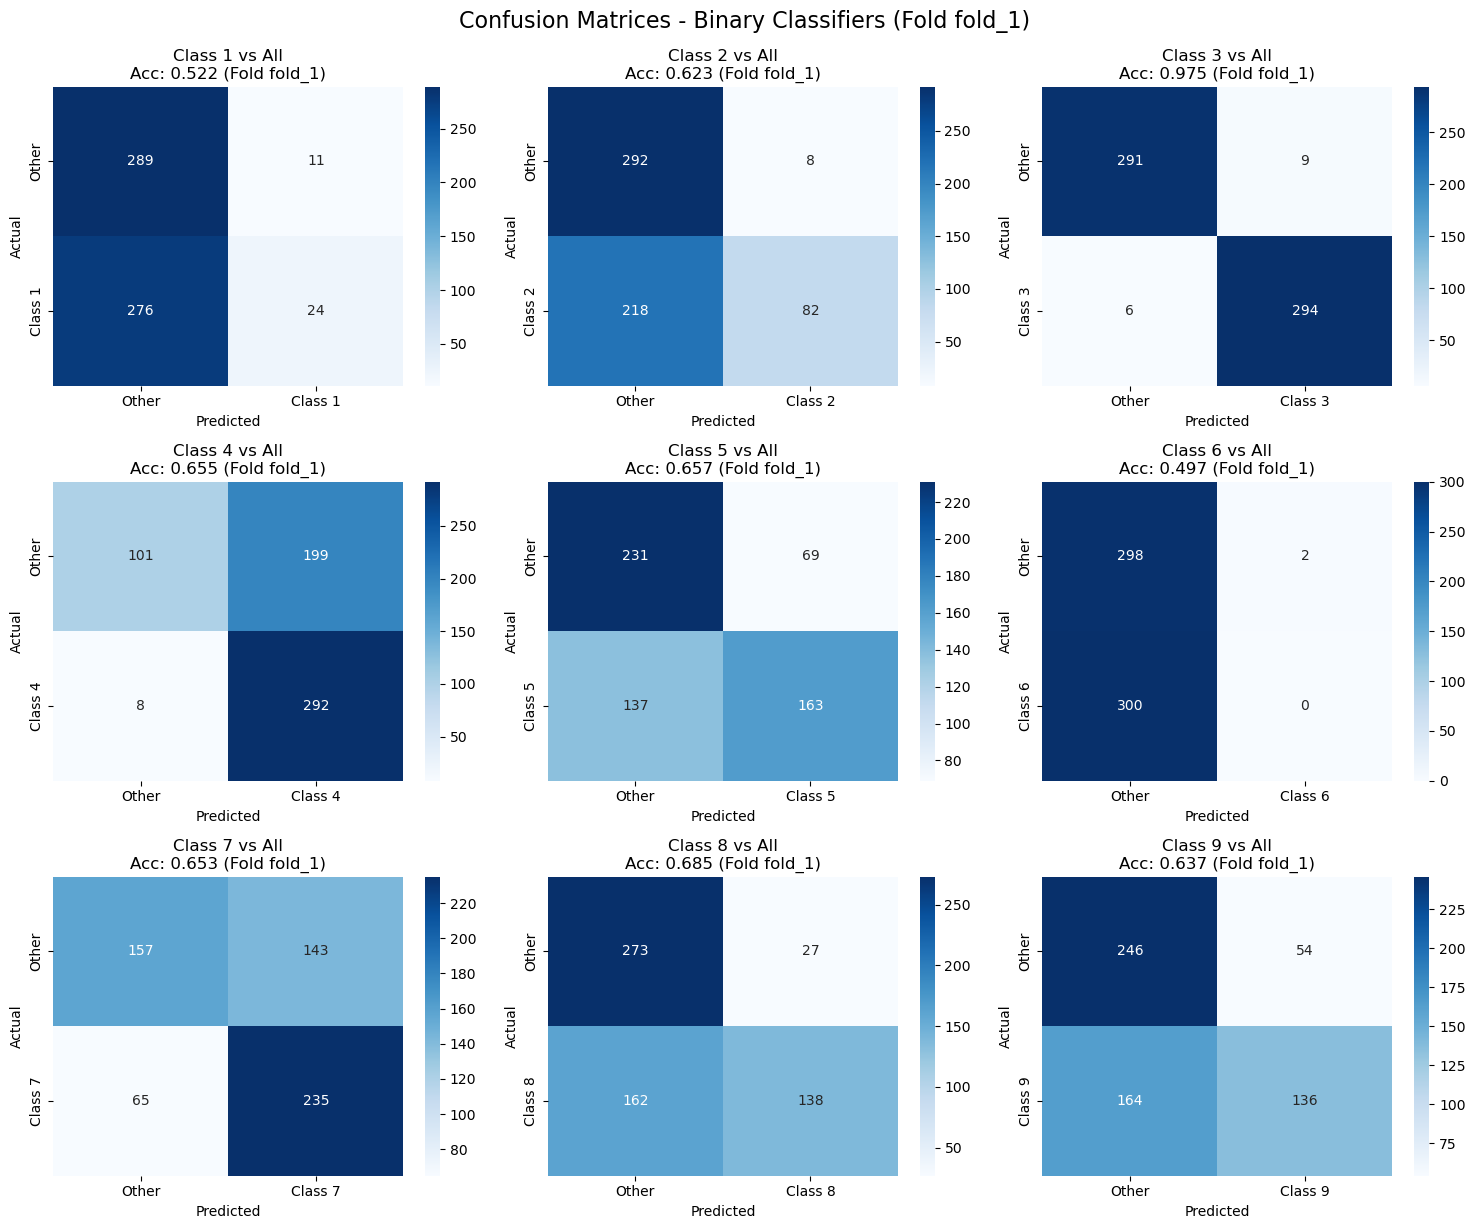

📊 Creating performance comparison plots...


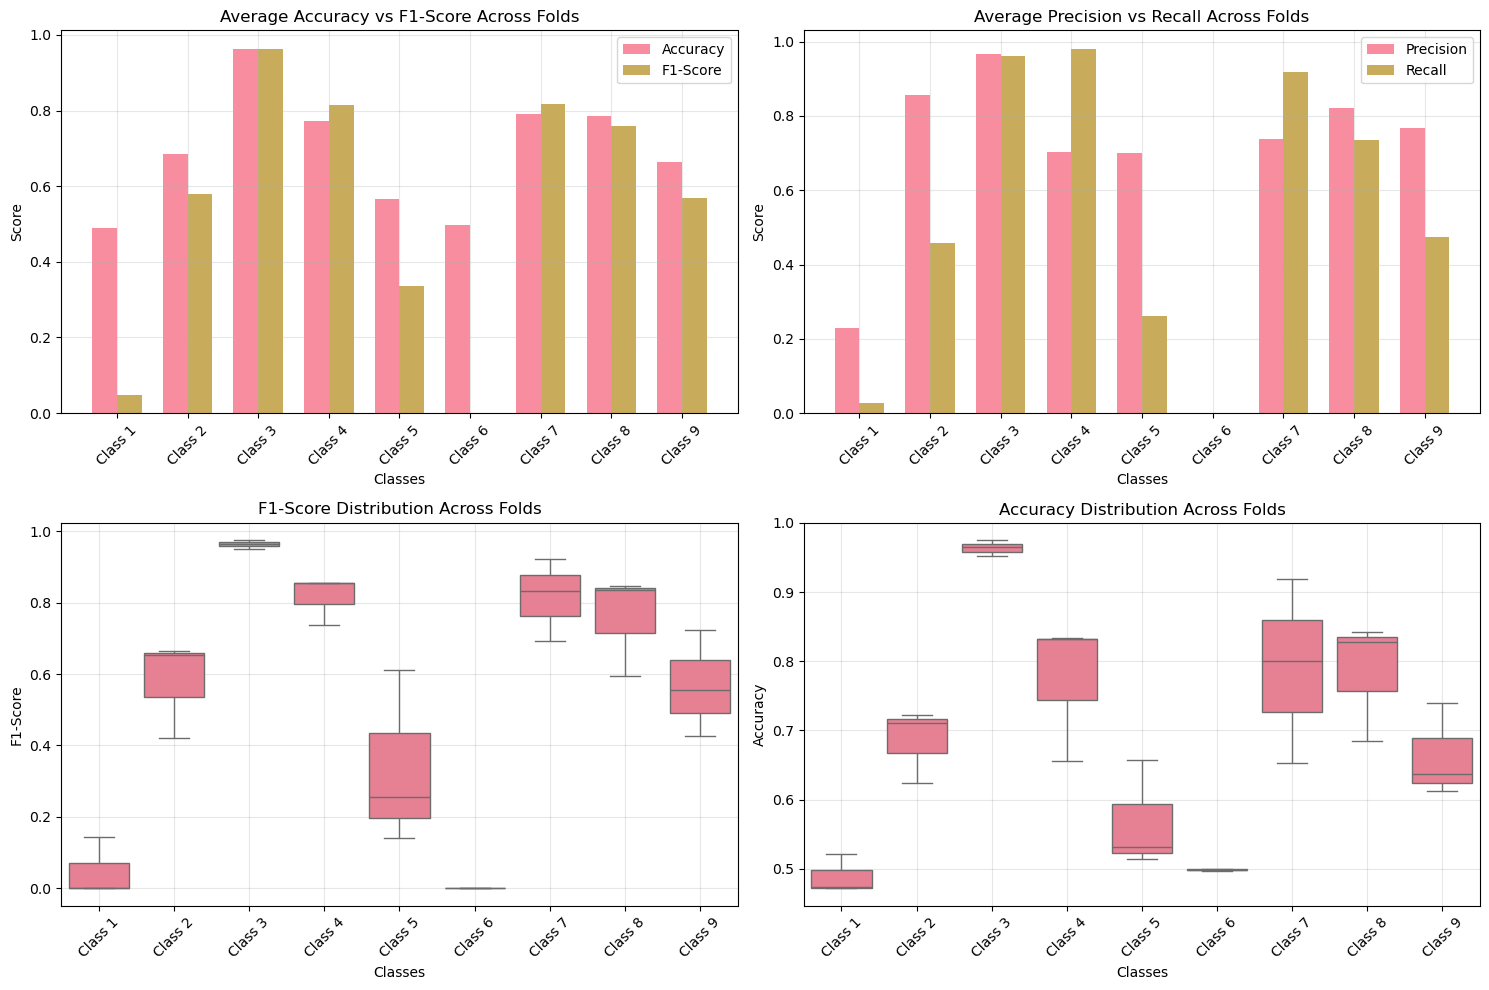

📁 Creating fold comparison plots...


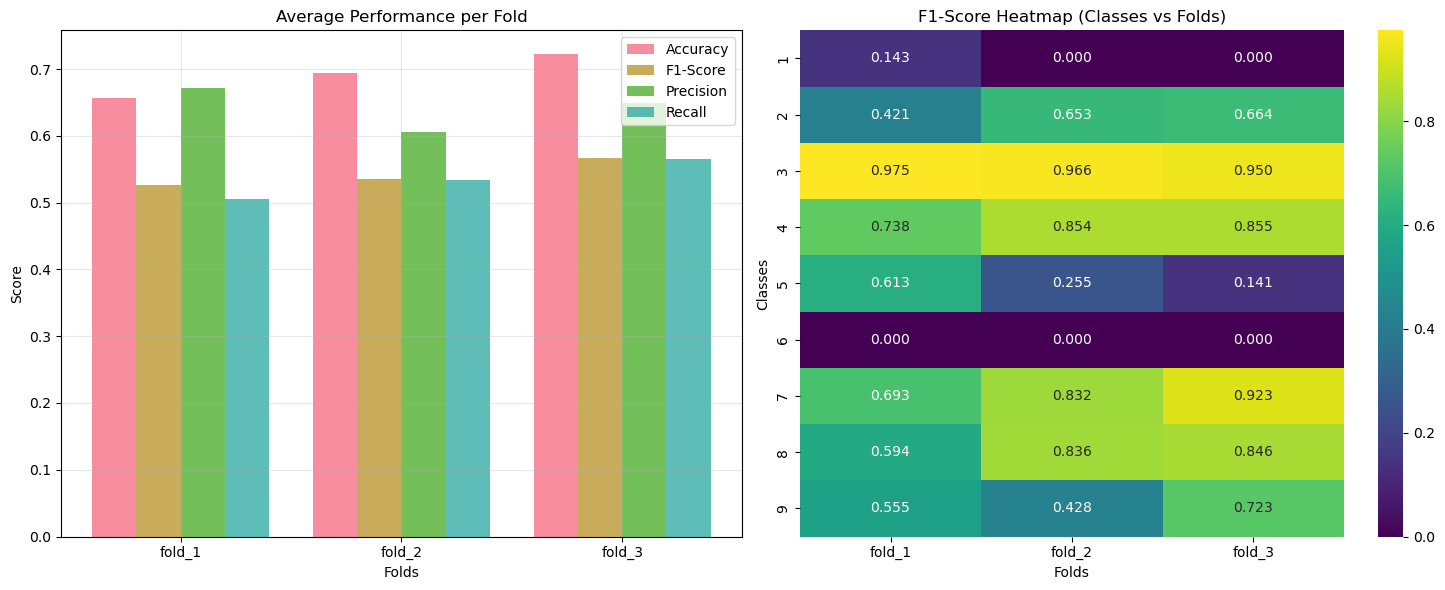

✅ All visualizations generated successfully!


In [9]:
# ============================================================
# VISUALIZATION AND ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

def plot_cv_confusion_matrices():
    """Plot confusion matrices for cross-validation results"""
    if 'cv_results' not in globals() or not cv_results:
        print("No cross-validation results available for visualization")
        return
    
    # Get results from the first fold for visualization
    first_fold = list(cv_results.keys())[0]
    fold_evaluation_results = cv_results[first_fold]['evaluation_results']
    
    n_classifiers = len(fold_evaluation_results)
    cols = min(3, n_classifiers)
    rows = (n_classifiers + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    if n_classifiers == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, (class_num, results) in enumerate(sorted(fold_evaluation_results.items())):
        ax = axes[idx]
        
        # Calculate confusion matrix from predictions
        y_true = results['true_labels']
        y_pred = results['predictions']
        cm = confusion_matrix(y_true, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Other', f'Class {class_num}'],
                   yticklabels=['Other', f'Class {class_num}'])
        
        ax.set_title(f'Class {class_num} vs All\nAcc: {results["accuracy"]:.3f} (Fold {first_fold})')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    
    # Hide unused subplots
    for idx in range(n_classifiers, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle(f'Confusion Matrices - Binary Classifiers (Fold {first_fold})', y=1.02, fontsize=16)
    plt.show()

def plot_cv_performance_comparison():
    """Plot performance metrics comparison across classes and folds"""
    if 'cv_detailed_results' not in globals() or cv_detailed_results.empty:
        print("No detailed CV results available for visualization")
        return
    
    # Create performance comparison plot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Average performance across folds
    avg_performance = cv_detailed_results.groupby('class').agg({
        'test_accuracy': 'mean',
        'test_precision': 'mean', 
        'test_recall': 'mean',
        'test_f1': 'mean'
    }).reset_index()
    
    classes = [f'Class {int(c)}' for c in avg_performance['class']]
    
    # Plot 1: Accuracy and F1-Score
    x = range(len(classes))
    width = 0.35
    ax1.bar([i - width/2 for i in x], avg_performance['test_accuracy'], width, label='Accuracy', alpha=0.8)
    ax1.bar([i + width/2 for i in x], avg_performance['test_f1'], width, label='F1-Score', alpha=0.8)
    ax1.set_xlabel('Classes')
    ax1.set_ylabel('Score')
    ax1.set_title('Average Accuracy vs F1-Score Across Folds')
    ax1.set_xticks(x)
    ax1.set_xticklabels(classes, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Precision and Recall
    ax2.bar([i - width/2 for i in x], avg_performance['test_precision'], width, label='Precision', alpha=0.8)
    ax2.bar([i + width/2 for i in x], avg_performance['test_recall'], width, label='Recall', alpha=0.8)
    ax2.set_xlabel('Classes')
    ax2.set_ylabel('Score')
    ax2.set_title('Average Precision vs Recall Across Folds')
    ax2.set_xticks(x)
    ax2.set_xticklabels(classes, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: F1-Score distribution across folds
    sns.boxplot(data=cv_detailed_results, x='class', y='test_f1', ax=ax3)
    ax3.set_xlabel('Classes')
    ax3.set_ylabel('F1-Score')
    ax3.set_title('F1-Score Distribution Across Folds')
    ax3.set_xticklabels([f'Class {int(c)}' for c in sorted(cv_detailed_results['class'].unique())], rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Accuracy distribution across folds
    sns.boxplot(data=cv_detailed_results, x='class', y='test_accuracy', ax=ax4)
    ax4.set_xlabel('Classes')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Accuracy Distribution Across Folds')
    ax4.set_xticklabels([f'Class {int(c)}' for c in sorted(cv_detailed_results['class'].unique())], rotation=45)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_fold_comparison():
    """Plot performance comparison across different folds"""
    if 'cv_detailed_results' not in globals() or cv_detailed_results.empty:
        print("No detailed CV results available for fold comparison")
        return
    
    # Create fold comparison plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Average performance per fold
    fold_avg = cv_detailed_results.groupby('fold').agg({
        'test_accuracy': 'mean',
        'test_f1': 'mean',
        'test_precision': 'mean',
        'test_recall': 'mean'
    }).reset_index()
    
    folds = fold_avg['fold']
    x = range(len(folds))
    width = 0.2
    
    ax1.bar([i - 1.5*width for i in x], fold_avg['test_accuracy'], width, label='Accuracy', alpha=0.8)
    ax1.bar([i - 0.5*width for i in x], fold_avg['test_f1'], width, label='F1-Score', alpha=0.8)
    ax1.bar([i + 0.5*width for i in x], fold_avg['test_precision'], width, label='Precision', alpha=0.8)
    ax1.bar([i + 1.5*width for i in x], fold_avg['test_recall'], width, label='Recall', alpha=0.8)
    
    ax1.set_xlabel('Folds')
    ax1.set_ylabel('Score')
    ax1.set_title('Average Performance per Fold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(folds)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Heatmap of F1-scores (classes vs folds)
    pivot_data = cv_detailed_results.pivot(index='class', columns='fold', values='test_f1')
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='viridis', ax=ax2)
    ax2.set_title('F1-Score Heatmap (Classes vs Folds)')
    ax2.set_xlabel('Folds')
    ax2.set_ylabel('Classes')
    
    plt.tight_layout()
    plt.show()

# ============================================================
# GENERATE VISUALIZATIONS
# ============================================================

print("📊 GENERATING CROSS-VALIDATION VISUALIZATIONS")
print("=" * 50)

if 'cv_results' in globals() and cv_results:
    print("✅ Cross-validation results found")
    print(f"   • Folds: {list(cv_results.keys())}")
    print(f"   • Classes per fold: {len(selected_classes)}")
    print()
    
    print("📈 Creating confusion matrices...")
    plot_cv_confusion_matrices()
    
    print("📊 Creating performance comparison plots...")
    plot_cv_performance_comparison()
    
    print("📁 Creating fold comparison plots...")
    plot_fold_comparison()
    
    print("✅ All visualizations generated successfully!")
    
else:
    print("❌ No cross-validation results available for visualization")
    print("Please run the cross-validation training cell first")

# Autoencoder latent use

In [10]:
# ============================================================
# PYTORCH AUTOENCODER IMPLEMENTATION
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class AutoencoderLSTM(nn.Module):
    """
    PyTorch LSTM-based Autoencoder for learning latent representations
    """
    def __init__(self, input_dim, timesteps, latent_dim=128, intermediate_dim=256):
        super(AutoencoderLSTM, self).__init__()
        
        self.input_dim = input_dim
        self.timesteps = timesteps
        self.latent_dim = latent_dim
        self.intermediate_dim = intermediate_dim
        
        # Encoder
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=intermediate_dim,
            batch_first=True,
            dropout=0.2
        )
        self.encoder_dense = nn.Linear(intermediate_dim, latent_dim)
        self.encoder_activation = nn.ReLU()
        
        # Decoder
        self.decoder_dense = nn.Linear(latent_dim, intermediate_dim)
        self.decoder_activation = nn.ReLU()
        self.decoder_lstm = nn.LSTM(
            input_size=intermediate_dim,
            hidden_size=intermediate_dim,
            batch_first=True,
            dropout=0.2
        )
        self.decoder_output = nn.Linear(intermediate_dim, input_dim)
        self.decoder_output_activation = nn.Sigmoid()
        
    def encode(self, x):
        """Encode input to latent representation"""
        # x shape: (batch_size, timesteps, input_dim)
        lstm_out, (hidden, cell) = self.encoder_lstm(x)
        # Use the last hidden state
        latent = self.encoder_dense(hidden[-1])  # hidden[-1] is the last layer's hidden state
        latent = self.encoder_activation(latent)
        return latent
    
    def decode(self, latent):
        """Decode latent representation back to original space"""
        # Expand latent to timesteps
        batch_size = latent.size(0)
        
        # Process latent through decoder dense layer
        decoded_h = self.decoder_dense(latent)
        decoded_h = self.decoder_activation(decoded_h)
        
        # Repeat for all timesteps
        decoded_h = decoded_h.unsqueeze(1).repeat(1, self.timesteps, 1)
        
        # Pass through LSTM
        lstm_out, _ = self.decoder_lstm(decoded_h)
        
        # Generate output
        output = self.decoder_output(lstm_out)
        output = self.decoder_output_activation(output)
        
        return output
    
    def forward(self, x):
        """Full autoencoder forward pass"""
        latent = self.encode(x)
        reconstructed = self.decode(latent)
        return reconstructed, latent

class Encoder(nn.Module):
    """
    Standalone encoder module extracted from autoencoder
    """
    def __init__(self, autoencoder_model):
        super(Encoder, self).__init__()
        self.encoder_lstm = autoencoder_model.encoder_lstm
        self.encoder_dense = autoencoder_model.encoder_dense
        self.encoder_activation = autoencoder_model.encoder_activation
        
    def forward(self, x):
        """Encode input to latent representation"""
        lstm_out, (hidden, cell) = self.encoder_lstm(x)
        latent = self.encoder_dense(hidden[-1])
        latent = self.encoder_activation(latent)
        return latent

def encode_data_in_batches(encoder, data, device='cpu', batch_size=32):
    """
    Encode data in batches to avoid memory issues
    
    Args:
        encoder: The encoder model
        data: Input data (numpy array)
        device: Device to run on
        batch_size: Batch size for processing
    
    Returns:
        encoded_data: Encoded data (numpy array)
    """
    encoder.eval()
    encoded_batches = []
    
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch_end = min(i + batch_size, len(data))
            batch_data = data[i:batch_end]
            
            # Convert to tensor and move to device
            batch_tensor = torch.FloatTensor(batch_data).to(device)
            
            # Encode batch
            batch_encoded = encoder(batch_tensor)
            
            # Move back to CPU and convert to numpy
            batch_encoded_cpu = batch_encoded.cpu().numpy()
            encoded_batches.append(batch_encoded_cpu)
            
            # Clear GPU memory
            del batch_tensor, batch_encoded
            if device.type == 'cuda':
                torch.cuda.empty_cache()
    
    # Concatenate all batches
    encoded_data = np.concatenate(encoded_batches, axis=0)
    return encoded_data

def create_autoencoder(input_train, input_test, device='cpu'):
    """
    Create PyTorch autoencoder model for learning latent representations
    
    Args:
        input_train: Training data with shape (samples, timesteps, features)
        input_test: Test data with shape (samples, timesteps, features)
        device: Device to run the model on ('cpu' or 'cuda')
    
    Returns:
        autoencoder: Full autoencoder model
        encoder: Standalone encoder model
    """
    # Parameters
    timesteps = input_train.shape[1]  # Number of timesteps in your data
    input_dim = input_train.shape[2]  # Number of features
    latent_dim = 128  # Dimension of the latent representation
    intermediate_dim = 256  # Size of intermediate layer
    
    print(f"Creating autoencoder with:")
    print(f"   • Input dimensions: {input_dim}")
    print(f"   • Timesteps: {timesteps}")
    print(f"   • Latent dimensions: {latent_dim}")
    print(f"   • Intermediate dimensions: {intermediate_dim}")
    print(f"   • Device: {device}")
    
    # Create autoencoder model
    autoencoder = AutoencoderLSTM(
        input_dim=input_dim,
        timesteps=timesteps,
        latent_dim=latent_dim,
        intermediate_dim=intermediate_dim
    ).to(device)
    
    # Create standalone encoder
    encoder = Encoder(autoencoder).to(device)
    
    print(f"✅ Autoencoder created successfully")
    print(f"   • Total parameters: {sum(p.numel() for p in autoencoder.parameters()):,}")
    print(f"   • Trainable parameters: {sum(p.numel() for p in autoencoder.parameters() if p.requires_grad):,}")
    
    return autoencoder, encoder

def train_autoencoder(autoencoder, train_data, test_data, device='cpu', 
                     epochs=50, batch_size=32, learning_rate=0.001, patience=10):
    """
    Train the autoencoder model
    
    Args:
        autoencoder: The autoencoder model
        train_data: Training data (numpy array)
        test_data: Test data (numpy array)
        device: Device to run training on
        epochs: Number of training epochs
        batch_size: Batch size for training
        learning_rate: Learning rate for optimizer
        patience: Early stopping patience
    
    Returns:
        training_history: Dictionary with training losses
    """
    print(f"🚀 Training autoencoder...")
    print(f"   • Training samples: {len(train_data)}")
    print(f"   • Test samples: {len(test_data)}")
    print(f"   • Epochs: {epochs}")
    print(f"   • Batch size: {batch_size}")
    print(f"   • Learning rate: {learning_rate}")
    
    # Clear GPU cache before training
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    # Convert to tensors
    train_tensor = torch.FloatTensor(train_data).to(device)
    test_tensor = torch.FloatTensor(test_data).to(device)
    
    # Create data loaders
    train_dataset = TensorDataset(train_tensor, train_tensor)  # Input = Target for autoencoder
    test_dataset = TensorDataset(test_tensor, test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Setup optimizer and loss
    optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    # Training history
    history = {
        'train_loss': [],
        'test_loss': []
    }
    
    best_test_loss = float('inf')
    patience_counter = 0
    
    autoencoder.train()
    
    for epoch in range(epochs):
        # Training phase
        train_loss = 0.0
        autoencoder.train()
        
        for batch_input, batch_target in train_loader:
            optimizer.zero_grad()
            
            reconstructed, latent = autoencoder(batch_input)
            loss = criterion(reconstructed, batch_target)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Clear intermediate tensors
            del reconstructed, latent, loss
            if device.type == 'cuda':
                torch.cuda.empty_cache()
        
        # Validation phase
        test_loss = 0.0
        autoencoder.eval()
        
        with torch.no_grad():
            for batch_input, batch_target in test_loader:
                reconstructed, latent = autoencoder(batch_input)
                loss = criterion(reconstructed, batch_target)
                test_loss += loss.item()
                
                # Clear intermediate tensors
                del reconstructed, latent, loss
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
        
        # Calculate average losses
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)
        
        # Early stopping
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            patience_counter = 0
            # Save best model state
            best_model_state = autoencoder.state_dict().copy()
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}: "
                  f"Train Loss: {avg_train_loss:.6f}, "
                  f"Test Loss: {avg_test_loss:.6f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Restore best model
    autoencoder.load_state_dict(best_model_state)
    
    print(f"✅ Training completed!")
    print(f"   • Best test loss: {best_test_loss:.6f}")
    print(f"   • Final epoch: {epoch+1}")
    
    # Final cleanup
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    return history

In [11]:
# ============================================================
# SINGLE AUTOENCODER TRAINING
# ============================================================

print("🚀 SINGLE AUTOENCODER TRAINING")
print("=" * 35)

# Check if we have data available
if 'X_train_full' not in globals() or 'X_test_full' not in globals():
    print("❌ Training and test data not available. Please run the data preparation cells first.")
    single_autoencoder = None
    single_encoder = None
else:
    print(f"✅ Data available:")
    print(f"   • Training data: {X_train_full.shape}")
    print(f"   • Test data: {X_test_full.shape}")
    print(f"   • Device: {device}")
    
    # ========================================
    # STEP 1: PREPARE BALANCED DATASET FOR AUTOENCODER TRAINING
    # ========================================
    
    print("\n🔧 PREPARING BALANCED DATASET FOR AUTOENCODER TRAINING")
    print("=" * 55)
    
    # Combine all training and test data
    all_data = np.concatenate([X_train_full, X_test_full], axis=0)
    all_labels = np.concatenate([y_train_full, y_test_full], axis=0)
    
    print(f"   • Total available data: {all_data.shape}")
    print(f"   • Class distribution: {dict(Counter(all_labels))}")
    
    # Sample balanced data for autoencoder training (500-1000 samples per class)
    samples_per_class = 2000  # Target samples per class
    autoencoder_indices = []
    
    print(f"\n   • Sampling {samples_per_class} windows per class for autoencoder training...")
    
    for class_num in selected_classes:
        class_indices = np.where(all_labels == class_num)[0]
        
        if len(class_indices) > samples_per_class:
            # Randomly sample if we have more than needed
            selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)
        else:
            # Use all available if we have less than needed
            selected_indices = class_indices
            
        autoencoder_indices.extend(selected_indices)
        print(f"     • Class {class_num}: {len(selected_indices)} samples (from {len(class_indices)} available)")
    
    # Create balanced dataset for autoencoder training
    autoencoder_indices = np.array(autoencoder_indices)
    np.random.shuffle(autoencoder_indices)  # Shuffle the indices
    
    autoencoder_data = all_data[autoencoder_indices]
    autoencoder_labels = all_labels[autoencoder_indices]
    
    print(f"\n   ✅ Balanced autoencoder training dataset created:")
    print(f"     • Total samples: {len(autoencoder_data)}")
    print(f"     • Data shape: {autoencoder_data.shape}")
    print(f"     • Class distribution: {dict(Counter(autoencoder_labels))}")
    
    # Split autoencoder data for training/validation
    from sklearn.model_selection import train_test_split
    ae_train_data, ae_val_data = train_test_split(
        autoencoder_data, test_size=0.2, random_state=42, 
        stratify=autoencoder_labels
    )
    
    print(f"     • Training samples: {len(ae_train_data)}")
    print(f"     • Validation samples: {len(ae_val_data)}")
    
    # ========================================
    # STEP 2: TRAIN SINGLE AUTOENCODER ON BALANCED DATA
    # ========================================
    
    print("\n🔧 TRAINING SINGLE AUTOENCODER ON BALANCED DATA")
    print("=" * 45)
    
    # Create and train autoencoder
    single_autoencoder, single_encoder = create_autoencoder(ae_train_data, ae_val_data, device=device)
    
    # Train autoencoder with appropriate settings
    autoencoder_history = train_autoencoder(
        single_autoencoder, ae_train_data, ae_val_data, device=device,
        epochs=50, batch_size=32, learning_rate=0.001, patience=15
    )
    
    print(f"\n✅ SINGLE AUTOENCODER TRAINING COMPLETED!")
    print("=" * 45)
    print(f"   • Autoencoder trained on balanced dataset with {len(ae_train_data)} samples")
    print(f"   • Validation on {len(ae_val_data)} samples")
    print(f"   • Variables created:")
    print(f"     - single_autoencoder: Full autoencoder model")
    print(f"     - single_encoder: Standalone encoder for feature extraction")
    print(f"     - autoencoder_history: Training history")
    print(f"   • Ready for binary classification training in next cells")
    
    # Clear intermediate variables to save memory
    del autoencoder_data, autoencoder_labels, ae_train_data, ae_val_data
    del all_data, all_labels, autoencoder_indices
    
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    print(f"   • Memory cleanup completed")
    print(f"   🚀 Ready to proceed with binary classification training!")

🚀 SINGLE AUTOENCODER TRAINING
✅ Data available:
   • Training data: (71625, 300, 4)
   • Test data: (16134, 300, 4)
   • Device: cuda

🔧 PREPARING BALANCED DATASET FOR AUTOENCODER TRAINING
   • Total available data: (87759, 300, 4)
   • Class distribution: {1: 12702, 2: 2070, 3: 6405, 4: 1512, 5: 5781, 6: 4572, 7: 35397, 8: 18852, 9: 468}

   • Sampling 2000 windows per class for autoencoder training...
     • Class 1: 2000 samples (from 12702 available)
     • Class 2: 2000 samples (from 2070 available)
     • Class 3: 2000 samples (from 6405 available)
     • Class 4: 1512 samples (from 1512 available)
     • Class 5: 2000 samples (from 5781 available)
     • Class 6: 2000 samples (from 4572 available)
     • Class 7: 2000 samples (from 35397 available)
     • Class 8: 2000 samples (from 18852 available)
     • Class 9: 468 samples (from 468 available)

   ✅ Balanced autoencoder training dataset created:
     • Total samples: 15980
     • Data shape: (15980, 300, 4)
     • Class dist

In [12]:
# ============================================================
# AUTOENCODER-BASED BINARY CLASSIFICATION
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

class LatentBinaryClassifier(nn.Module):
    """
    Binary classifier that works with latent representations from encoder
    Uses frozen encoder + new dense layers
    """
    def __init__(self, encoder, latent_dim=128, dense_units=64, dropout_rate=0.3):
        super(LatentBinaryClassifier, self).__init__()
        
        # Freeze encoder layers
        self.encoder = encoder
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        # Dense layers for classification
        self.fc1 = nn.Linear(latent_dim, dense_units)
        self.bn1 = nn.BatchNorm1d(dense_units)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(dense_units, dense_units // 2)
        self.dropout2 = nn.Dropout(dropout_rate / 2)
        
        # Output layer
        self.fc_out = nn.Linear(dense_units // 2, 1)
        
    def forward(self, x):
        # Get latent representation (frozen encoder)
        with torch.no_grad():
            latent = self.encoder(x)
        
        # Classification layers
        x = F.relu(self.fc1(latent))
        x = self.bn1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        
        # Output with sigmoid
        output = torch.sigmoid(self.fc_out(x))
        
        return output

def create_latent_binary_classifier(encoder, latent_dim=128, dense_units=64, dropout_rate=0.3, device='cpu'):
    """
    Create a binary classifier using frozen encoder + dense layers
    """
    model = LatentBinaryClassifier(
        encoder=encoder,
        latent_dim=latent_dim,
        dense_units=dense_units,
        dropout_rate=dropout_rate
    )
    model = model.to(device)
    return model

def train_latent_pytorch_model(encoder, X_train, y_train, X_val, y_val, latent_dim=128, 
                              epochs=50, batch_size=32, learning_rate=0.001, patience=10, device='cpu'):
    """
    Train a latent binary classifier using the same approach as original binary classifiers
    """
    # Create model
    model = create_latent_binary_classifier(encoder, latent_dim=latent_dim, device=device)
    
    # Loss function and optimizer (only train the new dense layers)
    criterion = nn.BCELoss()
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1).to(device)
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': []
    }
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_state_dict = None
    
    model.train()
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_losses = []
        train_predictions = []
        train_targets = []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Collect predictions for accuracy
            predictions = (outputs > 0.5).float()
            train_predictions.extend(predictions.cpu().numpy())
            train_targets.extend(y_batch.cpu().numpy())
            
        # Validation phase
        model.eval()
        val_losses = []
        val_predictions = []
        val_targets = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                val_losses.append(loss.item())
                
                # Collect predictions for accuracy
                predictions = (outputs > 0.5).float()
                val_predictions.extend(predictions.cpu().numpy())
                val_targets.extend(y_batch.cpu().numpy())
        
        # Calculate metrics
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        train_acc = accuracy_score(train_targets, train_predictions)
        val_acc = accuracy_score(val_targets, val_predictions)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state_dict = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"      Early stopping at epoch {epoch + 1}")
            break
    
    # Load best model
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    
    return model, history

def evaluate_latent_binary_classifier(model, X_test, y_test, device):
    """
    Evaluate latent binary classifier and return metrics
    """
    model.eval()
    
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.FloatTensor(y_test).to(device)
    
    with torch.no_grad():
        outputs = model(X_test_tensor)
        predictions = (outputs > 0.5).float().cpu().numpy().flatten()
    
    y_test_np = y_test_tensor.cpu().numpy().flatten()
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_np, predictions)
    precision = precision_score(y_test_np, predictions, zero_division=0)
    recall = recall_score(y_test_np, predictions, zero_division=0)
    f1 = f1_score(y_test_np, predictions, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

def train_latent_binary_classifiers(encoder, X_train, y_train, X_test, y_test, selected_classes, device='cpu', 
                                   epochs=50, batch_size=32, learning_rate=0.001, patience=10,
                                   train_samples_per_class=3000, val_samples_per_class=200, latent_dim=128):
    """
    Train latent binary classifiers for multiple classes using the same approach as original
    """
    binary_classifiers = {}
    training_results = {}
    training_histories = {}
    
    print(f"🚀 TRAINING LATENT BINARY CLASSIFIERS - ONE VS ALL (PyTorch)")
    print(f"Using frozen encoder + dense layers approach")
    print(f"Training samples per class: {train_samples_per_class}")
    print(f"Validation samples per class: {val_samples_per_class}")
    print(f"Using device: {device}")
    print("=" * 60)
    
    for class_idx, target_class in enumerate(selected_classes):
        print(f"📊 Training Latent Binary Classifier {class_idx + 1}/{len(selected_classes)}")
        print(f"Target Class: {target_class} vs All Others")
        print("-" * 40)
        
        try:
            # Prepare binary training data (balanced, same as original approach)
            from src.binary_classifiers import prepare_binary_data
            
            X_train_binary, y_train_binary, train_indices = prepare_binary_data(
                X_train, y_train, target_class, balance_classes=True,
                samples_per_class=train_samples_per_class
            )
            
            # Prepare binary validation data (balanced, same as original approach)
            X_val_binary, y_val_binary, val_indices = prepare_binary_data(
                X_test, y_test, target_class, balance_classes=True,
                samples_per_class=val_samples_per_class
            )
            
            print(f"Binary training data prepared:")
            print(f"   • Training samples: {len(X_train_binary)}")
            print(f"   • Training positive (class {target_class}): {np.sum(y_train_binary)} samples")
            print(f"   • Training negative (others): {len(y_train_binary) - np.sum(y_train_binary)} samples")
            print(f"   • Validation samples: {len(X_val_binary)}")
            print(f"   • Validation positive (class {target_class}): {np.sum(y_val_binary)} samples")
            print(f"   • Validation negative (others): {len(y_val_binary) - np.sum(y_val_binary)} samples")
            
            if len(X_train_binary) < 10:  # Minimum samples needed
                print(f"   ⚠️ Insufficient training samples for class {target_class}, skipping...")
                continue
                
            if len(X_val_binary) < 5:  # Minimum validation samples needed
                print(f"   ⚠️ Insufficient validation samples for class {target_class}, skipping...")
                continue
            
            print(f"   • Training started...")
            
            # Train latent binary classifier
            model, history = train_latent_pytorch_model(
                encoder, X_train_binary, y_train_binary,
                X_val_binary, y_val_binary, latent_dim=latent_dim,
                epochs=epochs, batch_size=batch_size, 
                learning_rate=learning_rate, patience=patience, device=device
            )
            
            # Store model and results
            binary_classifiers[target_class] = model
            training_histories[target_class] = history
            
            # Calculate training metrics
            train_results = evaluate_latent_binary_classifier(model, X_train_binary, y_train_binary, device)
            val_results = evaluate_latent_binary_classifier(model, X_val_binary, y_val_binary, device)
            
            # Store training results
            training_results[target_class] = {
                'train_accuracy': train_results['accuracy'],
                'train_precision': train_results['precision'],
                'train_recall': train_results['recall'],
                'train_f1': train_results['f1_score'],
                'val_accuracy': val_results['accuracy'],
                'val_precision': val_results['precision'],
                'val_recall': val_results['recall'],
                'val_f1': val_results['f1_score'],
                'train_samples': len(X_train_binary),
                'val_samples': len(X_val_binary),
                'positive_samples': np.sum(y_train_binary),
                'epochs_trained': len(history['train_loss'])
            }
            
            print(f"   ✅ Training completed")
            print(f"   • Epochs: {len(history['train_loss'])}")
            print(f"   • Final Training Accuracy: {train_results['accuracy']:.3f}")
            print(f"   • Final Training F1-Score: {train_results['f1_score']:.3f}")
            print(f"   • Final Validation Accuracy: {val_results['accuracy']:.3f}")
            print(f"   • Final Validation F1-Score: {val_results['f1_score']:.3f}")
            print()
            
        except Exception as e:
            print(f"   ❌ Training failed for class {target_class}: {str(e)}")
            print()
            continue
    
    print("🎯 LATENT BINARY CLASSIFIERS TRAINING SUMMARY")
    print("=" * 50)
    print(f"Successfully trained: {len(binary_classifiers)} out of {len(selected_classes)} classifiers")
    print(f"Trained classes: {list(binary_classifiers.keys())}")
    
    return binary_classifiers, training_results, training_histories

def evaluate_latent_binary_classifiers(binary_classifiers, X_test, y_test, device='cpu', 
                                      samples_per_class=200, balance_classes=True):
    """
    Evaluate all latent binary classifiers on test data using the same approach as original
    """
    evaluation_results = {}
    
    print("🔍 EVALUATING LATENT BINARY CLASSIFIERS ON TEST DATA (PyTorch)")
    if balance_classes:
        print(f"Using balanced evaluation with {samples_per_class} samples per class")
    else:
        print("Using all available test data (unbalanced)")
    print("=" * 60)
    
    for class_idx, (target_class, model) in enumerate(binary_classifiers.items()):
        print(f"📊 Evaluating Latent Binary Classifier {class_idx + 1}/{len(binary_classifiers)}")
        print(f"Target Class: {target_class} vs All Others")
        print("-" * 40)
        
        try:
            from src.binary_classifiers import prepare_binary_data
            
            if balance_classes:
                # Prepare balanced binary test data
                X_test_binary, y_test_binary, test_indices = prepare_binary_data(
                    X_test, y_test, target_class, balance_classes=True,
                    samples_per_class=samples_per_class
                )
            else:
                # Use all test data
                X_test_binary, y_test_binary, test_indices = prepare_binary_data(
                    X_test, y_test, target_class, balance_classes=False
                )
            
            print(f"   • Test samples: {len(X_test_binary)}")
            print(f"   • Positive samples: {np.sum(y_test_binary)}")
            print(f"   • Negative samples: {len(y_test_binary) - np.sum(y_test_binary)}")
            
            if len(X_test_binary) < 5:  # Minimum samples needed
                print(f"   ⚠️ Insufficient test samples for class {target_class}, skipping...")
                continue
            
            # Evaluate model
            test_results = evaluate_latent_binary_classifier(model, X_test_binary, y_test_binary, device)
            
            evaluation_results[target_class] = {
                'test_accuracy': test_results['accuracy'],
                'test_precision': test_results['precision'],
                'test_recall': test_results['recall'],
                'test_f1': test_results['f1_score'],
                'test_samples': len(X_test_binary),
                'positive_samples': np.sum(y_test_binary)
            }
            
            print(f"   ✅ Evaluation completed")
            print(f"   • Test Accuracy: {test_results['accuracy']:.3f}")
            print(f"   • Test Precision: {test_results['precision']:.3f}")
            print(f"   • Test Recall: {test_results['recall']:.3f}")
            print(f"   • Test F1-Score: {test_results['f1_score']:.3f}")
            print()
            
        except Exception as e:
            print(f"   ❌ Evaluation failed for class {target_class}: {str(e)}")
            print()
            continue
    
    print("🎯 LATENT BINARY CLASSIFIERS EVALUATION SUMMARY")
    print("=" * 50)
    print(f"Successfully evaluated: {len(evaluation_results)} out of {len(binary_classifiers)} classifiers")
    print(f"Evaluated classes: {list(evaluation_results.keys())}")
    
    return evaluation_results

# ============================================================
# LATENT BINARY CLASSIFICATION EXECUTION
# ============================================================

if 'single_autoencoder' not in globals() or single_autoencoder is None:
    print("❌ No trained autoencoder available. Please train the autoencoder first.")
else:
    print("🚀 LATENT BINARY CLASSIFICATION WITH SINGLE AUTOENCODER")
    print("=" * 55)
    
    # Use the trained encoder from single autoencoder
    print(f"✅ Using trained autoencoder encoder")
    print(f"   • Encoder will be frozen during binary classifier training")
    print(f"   • New dense layers will be trained for classification")
    print()
    
    # Check if we have fold information for cross-validation
    if len(set(test_fold_info_sequences)) <= 1:
        print("⚠️ No proper fold information available. Skipping cross-validation.")
        print("Note: Cross-validation requires multiple folds for proper evaluation.")
        print("Using single train/test split instead.")
        
        # Fallback: Single training on all data
        print("\n🔄 SINGLE TRAINING (NO CROSS-VALIDATION)")
        print("=" * 45)
        
        # Training parameters (same as original approach)
        epochs = 50
        batch_size = 32
        learning_rate = 0.001
        patience = 10
        
        # Train latent binary classifiers using all data
        latent_binary_classifiers, latent_training_results, latent_training_histories = train_latent_binary_classifiers(
            single_encoder, X_train_full, y_train_full, X_test_full, y_test_full, selected_classes,
            device,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            patience=patience,
            train_samples_per_class=3000,
            val_samples_per_class=200,
            latent_dim=128
        )
        
        # Evaluate on test set
        latent_evaluation_results = evaluate_latent_binary_classifiers(
            latent_binary_classifiers, X_test_full, y_test_full, device=device,
            samples_per_class=200, balance_classes=True
        )
        
        # Store results in CV format for consistency
        latent_cv_results = {
            'single_fold': {
                'training_results': latent_training_results,
                'evaluation_results': latent_evaluation_results,
                'models': latent_binary_classifiers
            }
        }
        latent_cv_models = {'single_fold': latent_binary_classifiers}
        
    else:
        print("🔄 CROSS-VALIDATION TRAINING AND EVALUATION")
        print("=" * 50)
        
        unique_folds = sorted(set(test_fold_info_sequences))
        print(f"Available folds: {unique_folds}")
        print(f"Training separate latent binary classifiers for each fold using fold-specific train/test data...")
        print()
        
        # Training parameters (same as original approach)
        epochs = 50
        batch_size = 32
        learning_rate = 0.001
        patience = 10
        
        # Storage for cross-validation results
        latent_cv_results = {}
        latent_cv_models = {}
        
        for fold in unique_folds:
            print(f"📁 FOLD {fold} - LATENT BINARY CLASSIFICATION")
            print("=" * 40)
            
            # Get fold-specific training data (from training set)
            train_mask = np.array(train_fold_info_sequences) == fold
            X_train_fold = X_train_full[train_mask]
            y_train_fold = y_train_full[train_mask]
            
            # Get fold-specific test data (from test set)
            test_mask = np.array(test_fold_info_sequences) == fold
            X_test_fold = X_test_full[test_mask]
            y_test_fold = y_test_full[test_mask]
            
            print(f"Data for Fold {fold}:")
            print(f"   • Training samples: {len(X_train_fold)} (from fold {fold} training data)")
            print(f"   • Test samples: {len(X_test_fold)} (from fold {fold} test data)")
            print(f"   • Training classes: {dict(Counter(y_train_fold))}")
            print(f"   • Test classes: {dict(Counter(y_test_fold))}")
            print()
            
            # Check if fold has sufficient data
            if len(X_train_fold) == 0 or len(X_test_fold) == 0:
                print(f"⚠️ Fold {fold} has insufficient data. Skipping...")
                continue
            
            # Train latent binary classifiers for this fold
            print(f"🚀 Training latent models for Fold {fold}...")
            fold_latent_binary_classifiers, fold_latent_training_results, fold_latent_training_histories = train_latent_binary_classifiers(
                single_encoder, X_train_fold, y_train_fold, X_test_fold, y_test_fold, selected_classes,
                device,
                epochs=epochs,
                batch_size=batch_size,
                learning_rate=learning_rate,
                patience=patience,
                train_samples_per_class=3000,
                val_samples_per_class=300,
                latent_dim=128
            )
            
            # Evaluate on fold test set
            print(f"📊 Evaluating latent models for Fold {fold}...")
            fold_latent_evaluation_results = evaluate_latent_binary_classifiers(
                fold_latent_binary_classifiers, X_test_fold, y_test_fold, device=device,
                samples_per_class=300, balance_classes=True
            )
            
            # Store results
            latent_cv_results[fold] = {
                'training_results': fold_latent_training_results,
                'evaluation_results': fold_latent_evaluation_results,
                'models': fold_latent_binary_classifiers,
                'train_samples': len(X_train_fold),
                'test_samples': len(X_test_fold)
            }
            latent_cv_models[fold] = fold_latent_binary_classifiers
            
            print(f"✅ Fold {fold} completed successfully")
            print(f"   • Models trained: {len(fold_latent_binary_classifiers)}")
            print(f"   • Classes evaluated: {list(fold_latent_evaluation_results.keys())}")
            print("-" * 50)
            print()
        
        print("🎯 LATENT CROSS-VALIDATION SUMMARY")
        print("=" * 40)
        print(f"Successfully completed cross-validation for {len(latent_cv_results)} folds")
        print(f"Classes trained per fold: {selected_classes}")
        print(f"Models per fold: {len(selected_classes)}")
        print(f"Total latent models trained: {len(latent_cv_results) * len(selected_classes)}")
        print(f"Folds: {list(latent_cv_results.keys())}")
    
    print("\n✅ Latent binary classification training and evaluation completed!")
    print("Results stored in 'latent_cv_results' and 'latent_cv_models' variables")
    print("🔍 Ready for results analysis and comparison with original approach")

🚀 LATENT BINARY CLASSIFICATION WITH SINGLE AUTOENCODER
✅ Using trained autoencoder encoder
   • Encoder will be frozen during binary classifier training
   • New dense layers will be trained for classification

🔄 CROSS-VALIDATION TRAINING AND EVALUATION
Available folds: ['fold_1', 'fold_2', 'fold_3']
Training separate latent binary classifiers for each fold using fold-specific train/test data...

📁 FOLD fold_1 - LATENT BINARY CLASSIFICATION
Data for Fold fold_1:
   • Training samples: 25164 (from fold fold_1 training data)
   • Test samples: 4089 (from fold fold_1 test data)
   • Training classes: {1: 4180, 2: 619, 3: 1895, 4: 334, 5: 1844, 6: 1515, 7: 9265, 8: 5397, 9: 115}
   • Test classes: {1: 54, 2: 71, 3: 240, 4: 170, 5: 83, 6: 9, 7: 2534, 8: 887, 9: 41}

🚀 Training latent models for Fold fold_1...
🚀 TRAINING LATENT BINARY CLASSIFIERS - ONE VS ALL (PyTorch)
Using frozen encoder + dense layers approach
Training samples per class: 3000
Validation samples per class: 300
Using device

In [13]:
# ============================================================
# COMPREHENSIVE RESULTS COMPARISON AND SUMMARY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔍 COMPREHENSIVE RESULTS COMPARISON AND SUMMARY")
print("=" * 55)

# ============================================================
# CHECK DATA AVAILABILITY
# ============================================================

original_available = 'cv_results' in globals() and cv_results is not None
latent_available = 'latent_cv_results' in globals() and latent_cv_results is not None

print(f"📊 Data Availability:")
print(f"   • Original LSTM Approach: {'✅ Available' if original_available else '❌ Not Available'}")
print(f"   • Autoencoder Latent Approach: {'✅ Available' if latent_available else '❌ Not Available'}")

if not original_available and not latent_available:
    print("\n❌ No results available for comparison. Please run the training cells first.")
    
elif original_available and not latent_available:
    print("\n⚠️ Only original LSTM results available.")
    
elif not original_available and latent_available:
    print("\n⚠️ Only autoencoder latent results available.")
    
else:
    print("\n✅ Both approaches completed - Ready for comprehensive comparison!")

# ============================================================
# EXTRACT AND ORGANIZE RESULTS
# ============================================================

def extract_results_from_cv(cv_results_dict, approach_name):
    """Extract results from cv_results format into standardized DataFrame"""
    results = []
    
    for fold, fold_data in cv_results_dict.items():
        if 'training_results' in fold_data and 'evaluation_results' in fold_data:
            training_results = fold_data['training_results']
            evaluation_results = fold_data['evaluation_results']
            
            for class_num in training_results.keys():
                if class_num in evaluation_results:
                    train_res = training_results[class_num]
                    eval_res = evaluation_results[class_num]
                    
                    results.append({
                        'approach': approach_name,
                        'fold': fold,
                        'class': class_num,
                        'train_accuracy': train_res.get('train_accuracy', train_res.get('val_accuracy', 0)),
                        'train_f1': train_res.get('train_f1', train_res.get('val_f1', 0)),
                        'test_accuracy': eval_res.get('accuracy', eval_res.get('test_accuracy', 0)),
                        'test_precision': eval_res.get('precision', eval_res.get('test_precision', 0)),
                        'test_recall': eval_res.get('recall', eval_res.get('test_recall', 0)),
                        'test_f1': eval_res.get('f1_score', eval_res.get('test_f1', 0)),
                        'train_samples': train_res.get('train_samples', 0),
                        'test_samples': eval_res.get('test_samples', 0)
                    })
    
    return pd.DataFrame(results)

# Extract results from both approaches
all_results = []

if original_available:
    print(f"\n📋 EXTRACTING ORIGINAL LSTM RESULTS")
    print("-" * 35)
    original_df = extract_results_from_cv(cv_results, "Original LSTM")
    all_results.append(original_df)
    print(f"   • Extracted {len(original_df)} records from original approach")
    print(f"   • Folds: {sorted(original_df['fold'].unique())}")
    print(f"   • Classes: {sorted(original_df['class'].unique())}")

if latent_available:
    print(f"\n📋 EXTRACTING AUTOENCODER LATENT RESULTS")
    print("-" * 40)
    latent_df = extract_results_from_cv(latent_cv_results, "Autoencoder Latent")
    all_results.append(latent_df)
    print(f"   • Extracted {len(latent_df)} records from latent approach")
    print(f"   • Folds: {sorted(latent_df['fold'].unique())}")
    print(f"   • Classes: {sorted(latent_df['class'].unique())}")

# Combine all results
if all_results:
    comparison_df = pd.concat(all_results, ignore_index=True)
    print(f"\n✅ Combined Results: {len(comparison_df)} total records")
    
    # ============================================================
    # OVERALL PERFORMANCE COMPARISON
    # ============================================================
    
    print(f"\n🎯 OVERALL PERFORMANCE COMPARISON")
    print("=" * 40)
    
    overall_comparison = comparison_df.groupby('approach').agg({
        'test_accuracy': ['mean', 'std', 'count'],
        'test_precision': ['mean', 'std'],
        'test_recall': ['mean', 'std'],
        'test_f1': ['mean', 'std'],
        'train_samples': 'mean',
        'test_samples': 'mean'
    }).round(4)
    
    print(f"{'Approach':<20} {'Test Acc':<12} {'Test Prec':<12} {'Test Rec':<12} {'Test F1':<12} {'Records'}")
    print("-" * 85)
    
    for approach in comparison_df['approach'].unique():
        approach_data = comparison_df[comparison_df['approach'] == approach]
        acc_mean = approach_data['test_accuracy'].mean()
        acc_std = approach_data['test_accuracy'].std()
        prec_mean = approach_data['test_precision'].mean()
        prec_std = approach_data['test_precision'].std()
        rec_mean = approach_data['test_recall'].mean()
        rec_std = approach_data['test_recall'].std()
        f1_mean = approach_data['test_f1'].mean()
        f1_std = approach_data['test_f1'].std()
        count = len(approach_data)
        
        print(f"{approach:<20} {acc_mean:.3f}±{acc_std:.3f}   {prec_mean:.3f}±{prec_std:.3f}   "
              f"{rec_mean:.3f}±{rec_std:.3f}   {f1_mean:.3f}±{f1_std:.3f}   {count}")
    
    # ============================================================
    # PER-CLASS PERFORMANCE COMPARISON
    # ============================================================
    
    print(f"\n📊 PER-CLASS PERFORMANCE COMPARISON")
    print("=" * 40)
    
    class_comparison = comparison_df.groupby(['class', 'approach']).agg({
        'test_accuracy': 'mean',
        'test_f1': 'mean',
        'test_precision': 'mean',
        'test_recall': 'mean'
    }).round(4)
    
    print(f"Mean Test F1-Score per Class:")
    print(f"{'Class':<8}", end="")
    for approach in sorted(comparison_df['approach'].unique()):
        print(f"{approach:<18}", end="")
    print("Best Approach")
    print("-" * (8 + 18 * len(comparison_df['approach'].unique()) + 15))
    
    for class_num in sorted(comparison_df['class'].unique()):
        print(f"{class_num:<8}", end="")
        class_f1_scores = {}
        
        for approach in sorted(comparison_df['approach'].unique()):
            class_approach_data = comparison_df[
                (comparison_df['class'] == class_num) & 
                (comparison_df['approach'] == approach)
            ]
            if len(class_approach_data) > 0:
                f1_mean = class_approach_data['test_f1'].mean()
                class_f1_scores[approach] = f1_mean
                print(f"{f1_mean:<18.3f}", end="")
            else:
                print(f"{'N/A':<18}", end="")
        
        # Determine best approach for this class
        if class_f1_scores:
            best_approach = max(class_f1_scores.keys(), key=lambda x: class_f1_scores[x])
            improvement = max(class_f1_scores.values()) - min(class_f1_scores.values()) if len(class_f1_scores) > 1 else 0
            print(f"{best_approach:<15}")
        else:
            print("Unknown")
    
    # ============================================================
    # STATISTICAL SIGNIFICANCE AND IMPROVEMENT ANALYSIS
    # ============================================================
    
    if len(comparison_df['approach'].unique()) > 1:
        print(f"\n📈 IMPROVEMENT ANALYSIS")
        print("=" * 25)
        
        approaches = sorted(comparison_df['approach'].unique())
        if len(approaches) == 2:
            app1, app2 = approaches
            app1_data = comparison_df[comparison_df['approach'] == app1]
            app2_data = comparison_df[comparison_df['approach'] == app2]
            
            # Overall improvement
            app1_f1_mean = app1_data['test_f1'].mean()
            app2_f1_mean = app2_data['test_f1'].mean()
            improvement = app2_f1_mean - app1_f1_mean
            improvement_pct = (improvement / app1_f1_mean) * 100
            
            print(f"Overall F1-Score Comparison:")
            print(f"   • {app1}: {app1_f1_mean:.4f}")
            print(f"   • {app2}: {app2_f1_mean:.4f}")
            print(f"   • Improvement: {improvement:+.4f} ({improvement_pct:+.1f}%)")
            
            if improvement > 0.01:
                print(f"   ✅ {app2} shows significant improvement")
            elif improvement > -0.01:
                print(f"   🔵 Approaches perform similarly")
            else:
                print(f"   ⚠️ {app1} performs better")
            
            # Per-class improvements
            print(f"\nPer-Class Improvements ({app2} vs {app1}):")
            print(f"{'Class':<8} {'Original':<10} {'New':<10} {'Improvement':<12} {'Status'}")
            print("-" * 50)
            
            for class_num in sorted(comparison_df['class'].unique()):
                app1_class_data = app1_data[app1_data['class'] == class_num]
                app2_class_data = app2_data[app2_data['class'] == class_num]
                
                if len(app1_class_data) > 0 and len(app2_class_data) > 0:
                    app1_f1 = app1_class_data['test_f1'].mean()
                    app2_f1 = app2_class_data['test_f1'].mean()
                    class_improvement = app2_f1 - app1_f1
                    
                    if class_improvement > 0.02:
                        status = "✅ Better"
                    elif class_improvement > -0.02:
                        status = "🔵 Similar"
                    else:
                        status = "⚠️ Worse"
                    
                    print(f"{class_num:<8} {app1_f1:<10.3f} {app2_f1:<10.3f} {class_improvement:+<12.3f} {status}")
    
    # ============================================================
    # FOLD STABILITY ANALYSIS
    # ============================================================
    
    print(f"\n📊 FOLD STABILITY ANALYSIS")
    print("=" * 30)
    
    fold_stability = comparison_df.groupby(['approach', 'class']).agg({
        'test_f1': ['std', 'count']
    }).round(4)
    
    print(f"F1-Score Standard Deviation Across Folds (Lower = More Stable):")
    print(f"{'Class':<8}", end="")
    for approach in sorted(comparison_df['approach'].unique()):
        print(f"{approach:<18}", end="")
    print("Most Stable")
    print("-" * (8 + 18 * len(comparison_df['approach'].unique()) + 15))
    
    for class_num in sorted(comparison_df['class'].unique()):
        print(f"{class_num:<8}", end="")
        class_stds = {}
        
        for approach in sorted(comparison_df['approach'].unique()):
            class_approach_data = comparison_df[
                (comparison_df['class'] == class_num) & 
                (comparison_df['approach'] == approach)
            ]
            if len(class_approach_data) > 1:  # Need at least 2 folds for std
                f1_std = class_approach_data['test_f1'].std()
                class_stds[approach] = f1_std
                print(f"{f1_std:<18.4f}", end="")
            else:
                print(f"{'N/A':<18}", end="")
        
        # Determine most stable approach for this class
        if class_stds:
            most_stable = min(class_stds.keys(), key=lambda x: class_stds[x])
            print(f"{most_stable:<15}")
        else:
            print("Unknown")
    
    # ============================================================
    # SUMMARY AND RECOMMENDATIONS
    # ============================================================
    
    print(f"\n🎯 SUMMARY AND RECOMMENDATIONS")
    print("=" * 35)
    
    if len(comparison_df['approach'].unique()) > 1:
        # Overall best approach
        approach_means = comparison_df.groupby('approach')['test_f1'].mean()
        best_overall_approach = approach_means.idxmax()
        best_f1 = approach_means.max()
        
        print(f"🏆 Best Overall Approach: {best_overall_approach}")
        print(f"   • Average F1-Score: {best_f1:.4f}")
        
        # Count wins per approach
        approach_wins = {}
        for class_num in sorted(comparison_df['class'].unique()):
            class_means = comparison_df[comparison_df['class'] == class_num].groupby('approach')['test_f1'].mean()
            if len(class_means) > 0:
                winner = class_means.idxmax()
                approach_wins[winner] = approach_wins.get(winner, 0) + 1
        
        print(f"\n📊 Class-Level Performance:")
        for approach, wins in sorted(approach_wins.items()):
            total_classes = len(comparison_df['class'].unique())
            print(f"   • {approach}: Best in {wins}/{total_classes} classes")
        
        # Technical insights
        print(f"\n💡 Technical Insights:")
        
        if original_available and latent_available:
            original_samples = comparison_df[comparison_df['approach'] == 'Original LSTM']['train_samples'].mean()
            latent_samples = comparison_df[comparison_df['approach'] == 'Autoencoder Latent']['train_samples'].mean()
            
            print(f"   • Original LSTM: Direct time series classification")
            print(f"     - Average training samples per class: {original_samples:.0f}")
            print(f"     - Architecture: Multi-layer LSTM with dense layers")
            print(f"   • Autoencoder Latent: Dimensionality reduction + classification")
            print(f"     - Average training samples per class: {latent_samples:.0f}")
            print(f"     - Architecture: Frozen encoder + dense classification layers")
            
            if 'single_autoencoder' in globals():
                input_dim = X_train_full.shape[2] if 'X_train_full' in globals() else 'Unknown'
                latent_dim = 128  # From the code
                print(f"     - Dimensionality reduction: {input_dim} → {latent_dim} features")
        
        # Final recommendation
        print(f"\n🎖️ FINAL RECOMMENDATION:")
        if best_overall_approach == "Autoencoder Latent":
            print("   ✅ Autoencoder-based approach is recommended")
            print("   • Better feature representation through unsupervised learning")
            print("   • More efficient training with reduced dimensionality")
            print("   • Potentially better generalization")
        else:
            print("   ✅ Original LSTM approach is recommended")
            print("   • Direct optimization for classification task")
            print("   • No information loss from dimensionality reduction")
            print("   • Simpler end-to-end training")
    
    else:
        single_approach = comparison_df['approach'].iloc[0]
        single_f1 = comparison_df['test_f1'].mean()
        print(f"📊 Results for {single_approach}:")
        print(f"   • Average F1-Score: {single_f1:.4f}")
        print(f"   • Classes evaluated: {len(comparison_df['class'].unique())}")
        print(f"   • Total evaluations: {len(comparison_df)}")
    
    # ============================================================
    # STORE RESULTS FOR FURTHER ANALYSIS
    # ============================================================
    
    print(f"\n💾 DATA STORAGE:")
    print(f"   • Comparison results stored in 'comparison_df' DataFrame")
    print(f"   • {len(comparison_df)} records available for further analysis")
    print(f"   • Ready for visualization and detailed statistical analysis")

print(f"\n" + "=" * 70)
print("✅ COMPREHENSIVE RESULTS COMPARISON COMPLETED!")
print("=" * 70)

🔍 COMPREHENSIVE RESULTS COMPARISON AND SUMMARY
📊 Data Availability:
   • Original LSTM Approach: ✅ Available
   • Autoencoder Latent Approach: ✅ Available

✅ Both approaches completed - Ready for comprehensive comparison!

📋 EXTRACTING ORIGINAL LSTM RESULTS
-----------------------------------
   • Extracted 27 records from original approach
   • Folds: ['fold_1', 'fold_2', 'fold_3']
   • Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9]

📋 EXTRACTING AUTOENCODER LATENT RESULTS
----------------------------------------
   • Extracted 27 records from latent approach
   • Folds: ['fold_1', 'fold_2', 'fold_3']
   • Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9]

✅ Combined Results: 54 total records

🎯 OVERALL PERFORMANCE COMPARISON
Approach             Test Acc     Test Prec    Test Rec     Test F1      Records
-------------------------------------------------------------------------------------
Original LSTM        0.691±0.162   0.642±0.329   0.535±0.392   0.543±0.349   27
Autoencoder Latent   0.697±0.154   0.69

# Multiclass Classifier Approach

Train a single multiclass classifier on all classes, then use the pre-last layer (before softmax) as latent features to build binary classifiers.

In [14]:
# ============================================================
# PYTORCH MULTICLASS CLASSIFIER IMPLEMENTATION
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class MulticlassLSTMClassifier(nn.Module):
    """
    PyTorch LSTM-based Multiclass Classifier that outputs features before final classification
    """
    def __init__(self, input_dim, timesteps, num_classes, lstm_units=128, dense_units=64, dropout_rate=0.3):
        super(MulticlassLSTMClassifier, self).__init__()
        
        self.input_dim = input_dim
        self.timesteps = timesteps
        self.num_classes = num_classes
        self.lstm_units = lstm_units
        self.dense_units = dense_units
        
        # LSTM layers
        self.lstm1 = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_units,
            batch_first=True,
            dropout=dropout_rate
        )
        self.bn1 = nn.BatchNorm1d(lstm_units)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.lstm2 = nn.LSTM(
            input_size=lstm_units,
            hidden_size=lstm_units // 2,
            batch_first=True,
            dropout=dropout_rate
        )
        self.bn2 = nn.BatchNorm1d(lstm_units // 2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Dense layers
        self.fc1 = nn.Linear(lstm_units // 2, dense_units)
        self.bn3 = nn.BatchNorm1d(dense_units)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        # Pre-final layer (this will be used as latent features)
        self.fc_latent = nn.Linear(dense_units, dense_units)
        self.dropout4 = nn.Dropout(dropout_rate / 2)
        
        # Final classification layer
        self.fc_out = nn.Linear(dense_units, num_classes)
        
    def forward(self, x, return_latent=False):
        """
        Forward pass with option to return latent features
        """
        # LSTM layers
        lstm_out, _ = self.lstm1(x)
        # Take last timestep
        lstm_out_last = lstm_out[:, -1, :]
        lstm_out_last = self.bn1(lstm_out_last)
        lstm_out_last = self.dropout1(lstm_out_last)
        
        # Second LSTM
        lstm_out_expanded = lstm_out_last.unsqueeze(1)
        lstm_out2, _ = self.lstm2(lstm_out_expanded)
        lstm_out2 = lstm_out2[:, -1, :]
        lstm_out2 = self.bn2(lstm_out2)
        lstm_out2 = self.dropout2(lstm_out2)
        
        # Dense layers
        x = F.relu(self.fc1(lstm_out2))
        x = self.bn3(x)
        x = self.dropout3(x)
        
        # Pre-final layer (latent features)
        latent_features = F.relu(self.fc_latent(x))
        latent_features = self.dropout4(latent_features)
        
        if return_latent:
            return latent_features
        
        # Final classification
        output = self.fc_out(latent_features)
        return output
    
    def get_latent_features(self, x):
        """Extract latent features (pre-final layer)"""
        with torch.no_grad():
            return self.forward(x, return_latent=True)

class MulticlassFeatureExtractor(nn.Module):
    """
    Standalone feature extractor from trained multiclass classifier
    """
    def __init__(self, multiclass_model):
        super(MulticlassFeatureExtractor, self).__init__()
        # Copy all layers except the final classification layer
        self.lstm1 = multiclass_model.lstm1
        self.bn1 = multiclass_model.bn1
        self.dropout1 = multiclass_model.dropout1
        self.lstm2 = multiclass_model.lstm2
        self.bn2 = multiclass_model.bn2
        self.dropout2 = multiclass_model.dropout2
        self.fc1 = multiclass_model.fc1
        self.bn3 = multiclass_model.bn3
        self.dropout3 = multiclass_model.dropout3
        self.fc_latent = multiclass_model.fc_latent
        self.dropout4 = multiclass_model.dropout4
        
    def forward(self, x):
        """Extract latent features"""
        # LSTM layers
        lstm_out, _ = self.lstm1(x)
        lstm_out_last = lstm_out[:, -1, :]
        lstm_out_last = self.bn1(lstm_out_last)
        lstm_out_last = self.dropout1(lstm_out_last)
        
        lstm_out_expanded = lstm_out_last.unsqueeze(1)
        lstm_out2, _ = self.lstm2(lstm_out_expanded)
        lstm_out2 = lstm_out2[:, -1, :]
        lstm_out2 = self.bn2(lstm_out2)
        lstm_out2 = self.dropout2(lstm_out2)
        
        # Dense layers
        x = F.relu(self.fc1(lstm_out2))
        x = self.bn3(x)
        x = self.dropout3(x)
        
        # Pre-final layer (latent features)
        latent_features = F.relu(self.fc_latent(x))
        latent_features = self.dropout4(latent_features)
        
        return latent_features

def extract_features_in_batches(feature_extractor, data, device='cpu', batch_size=32):
    """
    Extract features in batches to avoid memory issues
    """
    feature_extractor.eval()
    feature_batches = []
    
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch_end = min(i + batch_size, len(data))
            batch_data = data[i:batch_end]
            
            # Convert to tensor and move to device
            batch_tensor = torch.FloatTensor(batch_data).to(device)
            
            # Extract features
            batch_features = feature_extractor(batch_tensor)
            
            # Move back to CPU and convert to numpy
            batch_features_cpu = batch_features.cpu().numpy()
            feature_batches.append(batch_features_cpu)
            
            # Clear GPU memory
            del batch_tensor, batch_features
            if device.type == 'cuda':
                torch.cuda.empty_cache()
    
    # Concatenate all batches
    features = np.concatenate(feature_batches, axis=0)
    return features

def create_multiclass_classifier(input_train, input_test, num_classes, device='cpu'):
    """
    Create PyTorch multiclass classifier
    """
    # Parameters
    timesteps = input_train.shape[1]
    input_dim = input_train.shape[2]
    lstm_units = 128
    dense_units = 64
    dropout_rate = 0.3
    
    print(f"Creating multiclass classifier with:")
    print(f"   • Input dimensions: {input_dim}")
    print(f"   • Timesteps: {timesteps}")
    print(f"   • Number of classes: {num_classes}")
    print(f"   • LSTM units: {lstm_units}")
    print(f"   • Dense units: {dense_units}")
    print(f"   • Device: {device}")
    
    # Create multiclass classifier
    multiclass_model = MulticlassLSTMClassifier(
        input_dim=input_dim,
        timesteps=timesteps,
        num_classes=num_classes,
        lstm_units=lstm_units,
        dense_units=dense_units,
        dropout_rate=dropout_rate
    ).to(device)
    
    # Create feature extractor
    feature_extractor = MulticlassFeatureExtractor(multiclass_model).to(device)
    
    print(f"✅ Multiclass classifier created successfully")
    print(f"   • Total parameters: {sum(p.numel() for p in multiclass_model.parameters()):,}")
    print(f"   • Trainable parameters: {sum(p.numel() for p in multiclass_model.parameters() if p.requires_grad):,}")
    
    return multiclass_model, feature_extractor

def train_multiclass_classifier(multiclass_model, train_data, train_labels, test_data, test_labels, device='cpu',
                               epochs=50, batch_size=32, learning_rate=0.001, patience=15):
    """
    Train the multiclass classifier
    """
    print(f"🚀 Training multiclass classifier...")
    print(f"   • Training samples: {len(train_data)}")
    print(f"   • Test samples: {len(test_data)}")
    print(f"   • Classes: {len(np.unique(train_labels))}")
    print(f"   • Epochs: {epochs}")
    print(f"   • Batch size: {batch_size}")
    print(f"   • Learning rate: {learning_rate}")
    
    # Clear GPU cache before training
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    # Convert to tensors
    train_tensor = torch.FloatTensor(train_data).to(device)
    train_labels_tensor = torch.LongTensor(train_labels).to(device)
    test_tensor = torch.FloatTensor(test_data).to(device)
    test_labels_tensor = torch.LongTensor(test_labels).to(device)
    
    # Create data loaders
    train_dataset = TensorDataset(train_tensor, train_labels_tensor)
    test_dataset = TensorDataset(test_tensor, test_labels_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Setup optimizer and loss
    optimizer = optim.Adam(multiclass_model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    # Training history
    history = {
        'train_loss': [],
        'test_loss': [],
        'train_accuracy': [],
        'test_accuracy': []
    }
    
    best_test_loss = float('inf')
    patience_counter = 0
    best_state_dict = None
    
    multiclass_model.train()
    
    for epoch in range(epochs):
        # Training phase
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        multiclass_model.train()
        
        for batch_input, batch_labels in train_loader:
            optimizer.zero_grad()
            
            outputs = multiclass_model(batch_input)
            loss = criterion(outputs, batch_labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_labels.size(0)
            train_correct += (predicted == batch_labels).sum().item()
            
            # Clear intermediate tensors
            del outputs, loss
            if device.type == 'cuda':
                torch.cuda.empty_cache()
        
        # Validation phase
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        multiclass_model.eval()
        
        with torch.no_grad():
            for batch_input, batch_labels in test_loader:
                outputs = multiclass_model(batch_input)
                loss = criterion(outputs, batch_labels)
                test_loss += loss.item()
                
                # Calculate accuracy
                _, predicted = torch.max(outputs.data, 1)
                test_total += batch_labels.size(0)
                test_correct += (predicted == batch_labels).sum().item()
                
                # Clear intermediate tensors
                del outputs, loss
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
        
        # Calculate average losses and accuracies
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        train_accuracy = 100 * train_correct / train_total
        test_accuracy = 100 * test_correct / test_total
        
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)
        history['train_accuracy'].append(train_accuracy)
        history['test_accuracy'].append(test_accuracy)
        
        # Learning rate scheduling
        scheduler.step(avg_test_loss)
        
        # Early stopping
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            patience_counter = 0
            best_state_dict = multiclass_model.state_dict().copy()
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}: "
                  f"Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, "
                  f"Train Acc: {train_accuracy:.2f}%, Test Acc: {test_accuracy:.2f}%")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Restore best model
    if best_state_dict is not None:
        multiclass_model.load_state_dict(best_state_dict)
    
    print(f"✅ Training completed!")
    print(f"   • Best test loss: {best_test_loss:.4f}")
    print(f"   • Final epoch: {epoch+1}")
    print(f"   • Final test accuracy: {history['test_accuracy'][-1]:.2f}%")
    
    # Final cleanup
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    return history

In [15]:
# ============================================================
# SINGLE MULTICLASS CLASSIFIER TRAINING
# ============================================================

print("🚀 SINGLE MULTICLASS CLASSIFIER TRAINING")
print("=" * 40)

# Check if we have data available
if 'X_train_full' not in globals() or 'X_test_full' not in globals():
    print("❌ Training and test data not available. Please run the data preparation cells first.")
    single_multiclass_model = None
    single_feature_extractor = None
else:
    print(f"✅ Data available:")
    print(f"   • Training data: {X_train_full.shape}")
    print(f"   • Test data: {X_test_full.shape}")
    print(f"   • Device: {device}")
    
    # ========================================
    # STEP 1: PREPARE BALANCED DATASET FOR MULTICLASS TRAINING
    # ========================================
    
    print("\n🔧 PREPARING BALANCED DATASET FOR MULTICLASS TRAINING")
    print("=" * 55)
    
    # Combine all training and test data
    all_data = np.concatenate([X_train_full, X_test_full], axis=0)
    all_labels = np.concatenate([y_train_full, y_test_full], axis=0)
    
    print(f"   • Total available data: {all_data.shape}")
    print(f"   • Class distribution: {dict(Counter(all_labels))}")
    
    # Sample balanced data for multiclass training (similar to autoencoder)
    samples_per_class = 2000  # Target samples per class
    multiclass_indices = []
    
    print(f"\n   • Sampling {samples_per_class} windows per class for multiclass training...")
    
    for class_num in selected_classes:
        class_indices = np.where(all_labels == class_num)[0]
        
        if len(class_indices) > samples_per_class:
            # Randomly sample if we have more than needed
            selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)
        else:
            # Use all available if we have less than needed
            selected_indices = class_indices
            
        multiclass_indices.extend(selected_indices)
        print(f"     • Class {class_num}: {len(selected_indices)} samples (from {len(class_indices)} available)")
    
    # Create balanced dataset for multiclass training
    multiclass_indices = np.array(multiclass_indices)
    np.random.shuffle(multiclass_indices)  # Shuffle the indices
    
    multiclass_data = all_data[multiclass_indices]
    multiclass_labels = all_labels[multiclass_indices]
    
    print(f"\n   ✅ Balanced multiclass training dataset created:")
    print(f"     • Total samples: {len(multiclass_data)}")
    print(f"     • Data shape: {multiclass_data.shape}")
    print(f"     • Class distribution: {dict(Counter(multiclass_labels))}")
    
    # Convert labels to 0-based indexing for PyTorch
    unique_classes = sorted(np.unique(multiclass_labels))
    class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}
    idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
    
    multiclass_labels_indexed = np.array([class_to_idx[cls] for cls in multiclass_labels])
    print(f"     • Class mapping: {class_to_idx}")
    
    # Split multiclass data for training/validation
    from sklearn.model_selection import train_test_split
    mc_train_data, mc_val_data, mc_train_labels, mc_val_labels = train_test_split(
        multiclass_data, multiclass_labels_indexed, test_size=0.2, random_state=42, 
        stratify=multiclass_labels_indexed
    )
    
    print(f"     • Training samples: {len(mc_train_data)}")
    print(f"     • Validation samples: {len(mc_val_data)}")
    print(f"     • Training class distribution: {dict(Counter(mc_train_labels))}")
    print(f"     • Validation class distribution: {dict(Counter(mc_val_labels))}")
    
    # ========================================
    # STEP 2: TRAIN SINGLE MULTICLASS CLASSIFIER
    # ========================================
    
    print("\n🔧 TRAINING SINGLE MULTICLASS CLASSIFIER")
    print("=" * 40)
    
    # Create multiclass classifier and feature extractor
    num_classes = len(unique_classes)
    single_multiclass_model, single_feature_extractor = create_multiclass_classifier(
        mc_train_data, mc_val_data, num_classes, device=device
    )
    
    # Train multiclass classifier
    multiclass_history = train_multiclass_classifier(
        single_multiclass_model, mc_train_data, mc_train_labels, 
        mc_val_data, mc_val_labels, device=device,
        epochs=50, batch_size=32, learning_rate=0.001, patience=15
    )
    
    print(f"\n✅ SINGLE MULTICLASS CLASSIFIER TRAINING COMPLETED!")
    print("=" * 50)
    print(f"   • Multiclass model trained on balanced dataset with {len(mc_train_data)} samples")
    print(f"   • Validation on {len(mc_val_data)} samples")
    print(f"   • Number of classes: {num_classes}")
    print(f"   • Final training accuracy: {multiclass_history['train_accuracy'][-1]:.2f}%")
    print(f"   • Final validation accuracy: {multiclass_history['test_accuracy'][-1]:.2f}%")
    print(f"   • Variables created:")
    print(f"     - single_multiclass_model: Full multiclass classifier")
    print(f"     - single_feature_extractor: Feature extractor (pre-final layer)")
    print(f"     - multiclass_history: Training history")
    print(f"     - class_to_idx, idx_to_class: Class mapping dictionaries")
    print(f"   • Ready for binary classification training using extracted features")
    
    # Clear intermediate variables to save memory
    del multiclass_data, multiclass_labels, multiclass_labels_indexed
    del mc_train_data, mc_val_data, mc_train_labels, mc_val_labels
    del all_data, all_labels, multiclass_indices
    
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    print(f"   • Memory cleanup completed")
    print(f"   🚀 Ready to proceed with multiclass-feature-based binary classification!")

🚀 SINGLE MULTICLASS CLASSIFIER TRAINING
✅ Data available:
   • Training data: (71625, 300, 4)
   • Test data: (16134, 300, 4)
   • Device: cuda

🔧 PREPARING BALANCED DATASET FOR MULTICLASS TRAINING
   • Total available data: (87759, 300, 4)
   • Class distribution: {1: 12702, 2: 2070, 3: 6405, 4: 1512, 5: 5781, 6: 4572, 7: 35397, 8: 18852, 9: 468}

   • Sampling 2000 windows per class for multiclass training...
     • Class 1: 2000 samples (from 12702 available)
     • Class 2: 2000 samples (from 2070 available)
     • Class 3: 2000 samples (from 6405 available)
     • Class 4: 1512 samples (from 1512 available)
     • Class 5: 2000 samples (from 5781 available)
     • Class 6: 2000 samples (from 4572 available)
     • Class 7: 2000 samples (from 35397 available)
     • Class 8: 2000 samples (from 18852 available)
     • Class 9: 468 samples (from 468 available)

   ✅ Balanced multiclass training dataset created:
     • Total samples: 15980
     • Data shape: (15980, 300, 4)
     • Cla

In [16]:
# ============================================================
# MULTICLASS-FEATURE-BASED BINARY CLASSIFICATION
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

class MulticlassFeatureBinaryClassifier(nn.Module):
    """
    Binary classifier that works with features from multiclass classifier
    Uses frozen feature extractor + new dense layers
    """
    def __init__(self, feature_extractor, feature_dim=64, dense_units=32, dropout_rate=0.3):
        super(MulticlassFeatureBinaryClassifier, self).__init__()
        
        # Freeze feature extractor layers
        self.feature_extractor = feature_extractor
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
        
        # Dense layers for binary classification
        self.fc1 = nn.Linear(feature_dim, dense_units)
        self.bn1 = nn.BatchNorm1d(dense_units)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(dense_units, dense_units // 2)
        self.dropout2 = nn.Dropout(dropout_rate / 2)
        
        # Output layer
        self.fc_out = nn.Linear(dense_units // 2, 1)
        
    def forward(self, x):
        # Get features from frozen feature extractor
        with torch.no_grad():
            features = self.feature_extractor(x)
        
        # Binary classification layers
        x = F.relu(self.fc1(features))
        x = self.bn1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        
        # Output with sigmoid
        output = torch.sigmoid(self.fc_out(x))
        
        return output

def create_multiclass_feature_binary_classifier(feature_extractor, feature_dim=64, dense_units=32, dropout_rate=0.3, device='cpu'):
    """
    Create a binary classifier using frozen multiclass feature extractor + dense layers
    """
    model = MulticlassFeatureBinaryClassifier(
        feature_extractor=feature_extractor,
        feature_dim=feature_dim,
        dense_units=dense_units,
        dropout_rate=dropout_rate
    )
    model = model.to(device)
    return model

def train_multiclass_feature_pytorch_model(feature_extractor, X_train, y_train, X_val, y_val, feature_dim=64,
                                         epochs=50, batch_size=32, learning_rate=0.001, patience=10, device='cpu'):
    """
    Train a multiclass-feature binary classifier using the same approach as previous binary classifiers
    """
    # Create model
    model = create_multiclass_feature_binary_classifier(feature_extractor, feature_dim=feature_dim, device=device)
    
    # Loss function and optimizer (only train the new dense layers)
    criterion = nn.BCELoss()
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1).to(device)
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_accuracy': [],
        'val_accuracy': []
    }
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_state_dict = None
    
    model.train()
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_losses = []
        train_predictions = []
        train_targets = []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Collect predictions for accuracy
            predictions = (outputs > 0.5).float()
            train_predictions.extend(predictions.cpu().numpy())
            train_targets.extend(y_batch.cpu().numpy())
            
        # Validation phase
        model.eval()
        val_losses = []
        val_predictions = []
        val_targets = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                val_losses.append(loss.item())
                
                # Collect predictions for accuracy
                predictions = (outputs > 0.5).float()
                val_predictions.extend(predictions.cpu().numpy())
                val_targets.extend(y_batch.cpu().numpy())
        
        # Calculate metrics
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        train_acc = accuracy_score(train_targets, train_predictions)
        val_acc = accuracy_score(val_targets, val_predictions)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state_dict = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"      Early stopping at epoch {epoch + 1}")
            break
    
    # Load best model
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    
    return model, history

def evaluate_multiclass_feature_binary_classifier(model, X_test, y_test, device):
    """
    Evaluate multiclass-feature binary classifier and return metrics
    """
    model.eval()
    
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.FloatTensor(y_test).to(device)
    
    with torch.no_grad():
        outputs = model(X_test_tensor)
        predictions = (outputs > 0.5).float().cpu().numpy().flatten()
    
    y_test_np = y_test_tensor.cpu().numpy().flatten()
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_np, predictions)
    precision = precision_score(y_test_np, predictions, zero_division=0)
    recall = recall_score(y_test_np, predictions, zero_division=0)
    f1 = f1_score(y_test_np, predictions, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

def train_multiclass_feature_binary_classifiers(feature_extractor, X_train, y_train, X_test, y_test, selected_classes, device='cpu',
                                              epochs=50, batch_size=32, learning_rate=0.001, patience=10,
                                              train_samples_per_class=3000, val_samples_per_class=200, feature_dim=64):
    """
    Train multiclass-feature binary classifiers for multiple classes using the same approach as original
    """
    binary_classifiers = {}
    training_results = {}
    training_histories = {}
    
    print(f"🚀 TRAINING MULTICLASS-FEATURE BINARY CLASSIFIERS - ONE VS ALL (PyTorch)")
    print(f"Using frozen multiclass feature extractor + dense layers approach")
    print(f"Training samples per class: {train_samples_per_class}")
    print(f"Validation samples per class: {val_samples_per_class}")
    print(f"Using device: {device}")
    print("=" * 70)
    
    for class_idx, target_class in enumerate(selected_classes):
        print(f"📊 Training Multiclass-Feature Binary Classifier {class_idx + 1}/{len(selected_classes)}")
        print(f"Target Class: {target_class} vs All Others")
        print("-" * 50)
        
        try:
            # Prepare binary training data (balanced, same as original approach)
            from src.binary_classifiers import prepare_binary_data
            
            X_train_binary, y_train_binary, train_indices = prepare_binary_data(
                X_train, y_train, target_class, balance_classes=True,
                samples_per_class=train_samples_per_class
            )
            
            # Prepare binary validation data (balanced, same as original approach)
            X_val_binary, y_val_binary, val_indices = prepare_binary_data(
                X_test, y_test, target_class, balance_classes=True,
                samples_per_class=val_samples_per_class
            )
            
            print(f"Binary training data prepared:")
            print(f"   • Training samples: {len(X_train_binary)}")
            print(f"   • Training positive (class {target_class}): {np.sum(y_train_binary)} samples")
            print(f"   • Training negative (others): {len(y_train_binary) - np.sum(y_train_binary)} samples")
            print(f"   • Validation samples: {len(X_val_binary)}")
            print(f"   • Validation positive (class {target_class}): {np.sum(y_val_binary)} samples")
            print(f"   • Validation negative (others): {len(y_val_binary) - np.sum(y_val_binary)} samples")
            
            if len(X_train_binary) < 10:  # Minimum samples needed
                print(f"   ⚠️ Insufficient training samples for class {target_class}, skipping...")
                continue
                
            if len(X_val_binary) < 5:  # Minimum validation samples needed
                print(f"   ⚠️ Insufficient validation samples for class {target_class}, skipping...")
                continue
            
            print(f"   • Training started...")
            
            # Train multiclass-feature binary classifier
            model, history = train_multiclass_feature_pytorch_model(
                feature_extractor, X_train_binary, y_train_binary,
                X_val_binary, y_val_binary, feature_dim=feature_dim,
                epochs=epochs, batch_size=batch_size,
                learning_rate=learning_rate, patience=patience, device=device
            )
            
            # Store model and results
            binary_classifiers[target_class] = model
            training_histories[target_class] = history
            
            # Calculate training metrics
            train_results = evaluate_multiclass_feature_binary_classifier(model, X_train_binary, y_train_binary, device)
            val_results = evaluate_multiclass_feature_binary_classifier(model, X_val_binary, y_val_binary, device)
            
            # Store training results
            training_results[target_class] = {
                'train_accuracy': train_results['accuracy'],
                'train_precision': train_results['precision'],
                'train_recall': train_results['recall'],
                'train_f1': train_results['f1_score'],
                'val_accuracy': val_results['accuracy'],
                'val_precision': val_results['precision'],
                'val_recall': val_results['recall'],
                'val_f1': val_results['f1_score'],
                'train_samples': len(X_train_binary),
                'val_samples': len(X_val_binary),
                'positive_samples': np.sum(y_train_binary),
                'epochs_trained': len(history['train_loss'])
            }
            
            print(f"   ✅ Training completed")
            print(f"   • Epochs: {len(history['train_loss'])}")
            print(f"   • Final Training Accuracy: {train_results['accuracy']:.3f}")
            print(f"   • Final Training F1-Score: {train_results['f1_score']:.3f}")
            print(f"   • Final Validation Accuracy: {val_results['accuracy']:.3f}")
            print(f"   • Final Validation F1-Score: {val_results['f1_score']:.3f}")
            print()
            
        except Exception as e:
            print(f"   ❌ Training failed for class {target_class}: {str(e)}")
            print()
            continue
    
    print("🎯 MULTICLASS-FEATURE BINARY CLASSIFIERS TRAINING SUMMARY")
    print("=" * 60)
    print(f"Successfully trained: {len(binary_classifiers)} out of {len(selected_classes)} classifiers")
    print(f"Trained classes: {list(binary_classifiers.keys())}")
    
    return binary_classifiers, training_results, training_histories

def evaluate_multiclass_feature_binary_classifiers(binary_classifiers, X_test, y_test, device='cpu',
                                                  samples_per_class=200, balance_classes=True):
    """
    Evaluate all multiclass-feature binary classifiers on test data using the same approach as original
    """
    evaluation_results = {}
    
    print("🔍 EVALUATING MULTICLASS-FEATURE BINARY CLASSIFIERS ON TEST DATA (PyTorch)")
    if balance_classes:
        print(f"Using balanced evaluation with {samples_per_class} samples per class")
    else:
        print("Using all available test data (unbalanced)")
    print("=" * 70)
    
    for class_idx, (target_class, model) in enumerate(binary_classifiers.items()):
        print(f"📊 Evaluating Multiclass-Feature Binary Classifier {class_idx + 1}/{len(binary_classifiers)}")
        print(f"Target Class: {target_class} vs All Others")
        print("-" * 50)
        
        try:
            from src.binary_classifiers import prepare_binary_data
            
            if balance_classes:
                # Prepare balanced binary test data
                X_test_binary, y_test_binary, test_indices = prepare_binary_data(
                    X_test, y_test, target_class, balance_classes=True,
                    samples_per_class=samples_per_class
                )
            else:
                # Use all test data
                X_test_binary, y_test_binary, test_indices = prepare_binary_data(
                    X_test, y_test, target_class, balance_classes=False
                )
            
            print(f"   • Test samples: {len(X_test_binary)}")
            print(f"   • Positive samples: {np.sum(y_test_binary)}")
            print(f"   • Negative samples: {len(y_test_binary) - np.sum(y_test_binary)}")
            
            if len(X_test_binary) < 5:  # Minimum samples needed
                print(f"   ⚠️ Insufficient test samples for class {target_class}, skipping...")
                continue
            
            # Evaluate model
            test_results = evaluate_multiclass_feature_binary_classifier(model, X_test_binary, y_test_binary, device)
            
            evaluation_results[target_class] = {
                'test_accuracy': test_results['accuracy'],
                'test_precision': test_results['precision'],
                'test_recall': test_results['recall'],
                'test_f1': test_results['f1_score'],
                'test_samples': len(X_test_binary),
                'positive_samples': np.sum(y_test_binary)
            }
            
            print(f"   ✅ Evaluation completed")
            print(f"   • Test Accuracy: {test_results['accuracy']:.3f}")
            print(f"   • Test Precision: {test_results['precision']:.3f}")
            print(f"   • Test Recall: {test_results['recall']:.3f}")
            print(f"   • Test F1-Score: {test_results['f1_score']:.3f}")
            print()
            
        except Exception as e:
            print(f"   ❌ Evaluation failed for class {target_class}: {str(e)}")
            print()
            continue
    
    print("🎯 MULTICLASS-FEATURE BINARY CLASSIFIERS EVALUATION SUMMARY")
    print("=" * 60)
    print(f"Successfully evaluated: {len(evaluation_results)} out of {len(binary_classifiers)} classifiers")
    print(f"Evaluated classes: {list(evaluation_results.keys())}")
    
    return evaluation_results

# ============================================================
# MULTICLASS-FEATURE BINARY CLASSIFICATION EXECUTION
# ============================================================

if 'single_multiclass_model' not in globals() or single_multiclass_model is None:
    print("❌ No trained multiclass model available. Please train the multiclass classifier first.")
else:
    print("🚀 MULTICLASS-FEATURE BINARY CLASSIFICATION WITH SINGLE MULTICLASS MODEL")
    print("=" * 70)
    
    # Use the trained feature extractor from single multiclass model
    print(f"✅ Using trained multiclass feature extractor")
    print(f"   • Feature extractor will be frozen during binary classifier training")
    print(f"   • New dense layers will be trained for binary classification")
    print()
    
    # Check if we have fold information for cross-validation
    if len(set(test_fold_info_sequences)) <= 1:
        print("⚠️ No proper fold information available. Skipping cross-validation.")
        print("Note: Cross-validation requires multiple folds for proper evaluation.")
        print("Using single train/test split instead.")
        
        # Fallback: Single training on all data
        print("\n🔄 SINGLE TRAINING (NO CROSS-VALIDATION)")
        print("=" * 45)
        
        # Training parameters (same as original approach)
        epochs = 50
        batch_size = 32
        learning_rate = 0.001
        patience = 10
        
        # Train multiclass-feature binary classifiers using all data
        mc_feature_binary_classifiers, mc_feature_training_results, mc_feature_training_histories = train_multiclass_feature_binary_classifiers(
            single_feature_extractor, X_train_full, y_train_full, X_test_full, y_test_full, selected_classes,
            device,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            patience=patience,
            train_samples_per_class=3000,
            val_samples_per_class=200,
            feature_dim=64
        )
        
        # Evaluate on test set
        mc_feature_evaluation_results = evaluate_multiclass_feature_binary_classifiers(
            mc_feature_binary_classifiers, X_test_full, y_test_full, device=device,
            samples_per_class=200, balance_classes=True
        )
        
        # Store results in CV format for consistency
        mc_feature_cv_results = {
            'single_fold': {
                'training_results': mc_feature_training_results,
                'evaluation_results': mc_feature_evaluation_results,
                'models': mc_feature_binary_classifiers
            }
        }
        mc_feature_cv_models = {'single_fold': mc_feature_binary_classifiers}
        
    else:
        print("🔄 CROSS-VALIDATION TRAINING AND EVALUATION")
        print("=" * 50)
        
        unique_folds = sorted(set(test_fold_info_sequences))
        print(f"Available folds: {unique_folds}")
        print(f"Training separate multiclass-feature binary classifiers for each fold using fold-specific train/test data...")
        print()
        
        # Training parameters (same as original approach)
        epochs = 50
        batch_size = 32
        learning_rate = 0.001
        patience = 10
        
        # Storage for cross-validation results
        mc_feature_cv_results = {}
        mc_feature_cv_models = {}
        
        for fold in unique_folds:
            print(f"📁 FOLD {fold} - MULTICLASS-FEATURE BINARY CLASSIFICATION")
            print("=" * 55)
            
            # Get fold-specific training data (from training set)
            train_mask = np.array(train_fold_info_sequences) == fold
            X_train_fold = X_train_full[train_mask]
            y_train_fold = y_train_full[train_mask]
            
            # Get fold-specific test data (from test set)
            test_mask = np.array(test_fold_info_sequences) == fold
            X_test_fold = X_test_full[test_mask]
            y_test_fold = y_test_full[test_mask]
            
            print(f"Data for Fold {fold}:")
            print(f"   • Training samples: {len(X_train_fold)} (from fold {fold} training data)")
            print(f"   • Test samples: {len(X_test_fold)} (from fold {fold} test data)")
            print(f"   • Training classes: {dict(Counter(y_train_fold))}")
            print(f"   • Test classes: {dict(Counter(y_test_fold))}")
            print()
            
            # Check if fold has sufficient data
            if len(X_train_fold) == 0 or len(X_test_fold) == 0:
                print(f"⚠️ Fold {fold} has insufficient data. Skipping...")
                continue
            
            # Train multiclass-feature binary classifiers for this fold
            print(f"🚀 Training multiclass-feature models for Fold {fold}...")
            fold_mc_feature_binary_classifiers, fold_mc_feature_training_results, fold_mc_feature_training_histories = train_multiclass_feature_binary_classifiers(
                single_feature_extractor, X_train_fold, y_train_fold, X_test_fold, y_test_fold, selected_classes,
                device,
                epochs=epochs,
                batch_size=batch_size,
                learning_rate=learning_rate,
                patience=patience,
                train_samples_per_class=3000,
                val_samples_per_class=300,
                feature_dim=64
            )
            
            # Evaluate on fold test set
            print(f"📊 Evaluating multiclass-feature models for Fold {fold}...")
            fold_mc_feature_evaluation_results = evaluate_multiclass_feature_binary_classifiers(
                fold_mc_feature_binary_classifiers, X_test_fold, y_test_fold, device=device,
                samples_per_class=300, balance_classes=True
            )
            
            # Store results
            mc_feature_cv_results[fold] = {
                'training_results': fold_mc_feature_training_results,
                'evaluation_results': fold_mc_feature_evaluation_results,
                'models': fold_mc_feature_binary_classifiers,
                'train_samples': len(X_train_fold),
                'test_samples': len(X_test_fold)
            }
            mc_feature_cv_models[fold] = fold_mc_feature_binary_classifiers
            
            print(f"✅ Fold {fold} completed successfully")
            print(f"   • Models trained: {len(fold_mc_feature_binary_classifiers)}")
            print(f"   • Classes evaluated: {list(fold_mc_feature_evaluation_results.keys())}")
            print("-" * 60)
            print()
        
        print("🎯 MULTICLASS-FEATURE CROSS-VALIDATION SUMMARY")
        print("=" * 50)
        print(f"Successfully completed cross-validation for {len(mc_feature_cv_results)} folds")
        print(f"Classes trained per fold: {selected_classes}")
        print(f"Models per fold: {len(selected_classes)}")
        print(f"Total multiclass-feature models trained: {len(mc_feature_cv_results) * len(selected_classes)}")
        print(f"Folds: {list(mc_feature_cv_results.keys())}")
    
    print("\n✅ Multiclass-feature binary classification training and evaluation completed!")
    print("Results stored in 'mc_feature_cv_results' and 'mc_feature_cv_models' variables")
    print("🔍 Ready for results analysis and comparison with other approaches")

🚀 MULTICLASS-FEATURE BINARY CLASSIFICATION WITH SINGLE MULTICLASS MODEL
✅ Using trained multiclass feature extractor
   • Feature extractor will be frozen during binary classifier training
   • New dense layers will be trained for binary classification

🔄 CROSS-VALIDATION TRAINING AND EVALUATION
Available folds: ['fold_1', 'fold_2', 'fold_3']
Training separate multiclass-feature binary classifiers for each fold using fold-specific train/test data...

📁 FOLD fold_1 - MULTICLASS-FEATURE BINARY CLASSIFICATION
Data for Fold fold_1:
   • Training samples: 25164 (from fold fold_1 training data)
   • Test samples: 4089 (from fold fold_1 test data)
   • Training classes: {1: 4180, 2: 619, 3: 1895, 4: 334, 5: 1844, 6: 1515, 7: 9265, 8: 5397, 9: 115}
   • Test classes: {1: 54, 2: 71, 3: 240, 4: 170, 5: 83, 6: 9, 7: 2534, 8: 887, 9: 41}

🚀 Training multiclass-feature models for Fold fold_1...
🚀 TRAINING MULTICLASS-FEATURE BINARY CLASSIFIERS - ONE VS ALL (PyTorch)
Using frozen multiclass feature e